# 08 - Slices Latest Model Visualization

This notebook loads every CSV from `outputs/validation/comparison/slices_latest/` and visualizes the full slice-level model portfolio.

## Files loaded
- `slice_metrics_logistic.csv`
- `slice_metrics_regression.csv`
- `best_variant_by_slice_logistic.csv`
- `best_variant_by_slice_regression.csv`

## Coach translation
- **Logistic models** predict `target_shot_in_10s`: *does this defensive context turn into an opponent shot soon?*
- **Regression models** predict `target_xt_10s`: *how dangerous is the opponent's next attacking window?*

## Metrics
- Logistic: `roc_auc`, `avg_precision` — higher is better.
- Regression: `r2`, `spearman` — higher is better; `rmse`, `mae` — lower is better.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 8)
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)

def find_repo_root() -> Path:
    for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parents[1] if len(Path.cwd().parents) > 1 else Path.cwd()]:
        if (candidate / 'outputs' / 'validation' / 'comparison' / 'slices_latest').exists():
            return candidate
    raise FileNotFoundError('Could not locate outputs/validation/comparison/slices_latest from current working directory.')

REPO_ROOT = find_repo_root()
SLICES_DIR = REPO_ROOT / 'outputs' / 'validation' / 'comparison' / 'slices_latest'

FILES = {
    'logistic': SLICES_DIR / 'slice_metrics_logistic.csv',
    'regression': SLICES_DIR / 'slice_metrics_regression.csv',
    'best_logistic': SLICES_DIR / 'best_variant_by_slice_logistic.csv',
    'best_regression': SLICES_DIR / 'best_variant_by_slice_regression.csv',
}
missing = [str(path) for path in FILES.values() if not path.exists()]
if missing:
    raise FileNotFoundError('Missing required files:\n' + '\n'.join(missing))

logistic = pd.read_csv(FILES['logistic'])
regression = pd.read_csv(FILES['regression'])
best_logistic = pd.read_csv(FILES['best_logistic'])
best_regression = pd.read_csv(FILES['best_regression'])

# Numeric safety.
for df_, cols in [
    (logistic, ['n', 'roc_auc', 'avg_precision']),
    (best_logistic, ['n', 'roc_auc', 'avg_precision']),
    (regression, ['n', 'r2', 'rmse', 'mae', 'spearman']),
    (best_regression, ['n', 'r2', 'rmse', 'mae', 'spearman']),
]:
    for col in cols:
        if col in df_.columns:
            df_[col] = pd.to_numeric(df_[col], errors='coerce')

print(f'Repository root: {REPO_ROOT}')
print(f'Slices latest directory: {SLICES_DIR}')
print()
for name, path in FILES.items():
    print(f'{name:16s}: {path.name}')
print()
print(f'Logistic rows: {len(logistic):,}')
print(f'Regression rows: {len(regression):,}')
print(f'Best logistic rows: {len(best_logistic):,}')
print(f'Best regression rows: {len(best_regression):,}')

Repository root: C:\Users\USER\Documents\Projects\defensive-action-expected
Slices latest directory: C:\Users\USER\Documents\Projects\defensive-action-expected\outputs\validation\comparison\slices_latest

logistic        : slice_metrics_logistic.csv
regression      : slice_metrics_regression.csv
best_logistic   : best_variant_by_slice_logistic.csv
best_regression : best_variant_by_slice_regression.csv

Logistic rows: 360
Regression rows: 360
Best logistic rows: 40
Best regression rows: 40


---
## 1. Data inventory and coverage

In [2]:
def inventory(df: pd.DataFrame, name: str) -> None:
    print(f'=== {name} ===')
    print(f'Variants: {df["variant"].nunique()}')
    print(f'Slice dimensions: {df["slice_col"].nunique()}')
    display(pd.DataFrame({'variant': sorted(df['variant'].dropna().unique())}))
    coverage = (
        df.groupby('slice_col')
        .agg(
            rows=('slice_value', 'size'),
            slice_values=('slice_value', 'nunique'),
            variants=('variant', 'nunique'),
            min_n=('n', 'min'),
            median_n=('n', 'median'),
            max_n=('n', 'max'),
        )
        .reset_index()
        .sort_values('slice_col')
    )
    display(coverage)

inventory(logistic, 'Logistic slice metrics')
inventory(regression, 'Regression slice metrics')

=== Logistic slice metrics ===
Variants: 9
Slice dimensions: 6


,variant
0,v0_phase_only
1,v1_spatial
2,v2_full_baseline
3,v3_context_enhanced
4,v4_freeze_geometry
5,v5_interpretable_clustered
6,v6_balanced_clustered
7,v7_interpretable_ridge
8,v8_balanced_ridge


,slice_col,rows,slice_values,variants,min_n,median_n,max_n
0,action_family,54,6,9,1469,7921.0,27478
1,action_zone,81,9,9,3210,5717.0,12110
2,counterpress,18,2,9,8690,28818.5,48947
3,phase_label,72,8,9,4070,6654.0,9797
4,play_pattern,72,8,9,759,3856.0,24821
5,position_group,63,7,9,2346,10229.0,10844


=== Regression slice metrics ===
Variants: 9
Slice dimensions: 6


,variant
0,v0_phase_only
1,v1_spatial
2,v2_full_baseline
3,v3_context_enhanced
4,v4_freeze_geometry
5,v5_interpretable_clustered
6,v6_balanced_clustered
7,v7_interpretable_ridge
8,v8_balanced_ridge


,slice_col,rows,slice_values,variants,min_n,median_n,max_n
0,action_family,54,6,9,1469,7921.0,27478
1,action_zone,81,9,9,3210,5717.0,12110
2,counterpress,18,2,9,8690,28818.5,48947
3,phase_label,72,8,9,4070,6654.0,9797
4,play_pattern,72,8,9,759,3856.0,24821
5,position_group,63,7,9,2346,10229.0,10844


---
## 2. Metric distributions across all slices and variants

This answers: *are the model scores generally strong, weak, or variable across football contexts?*

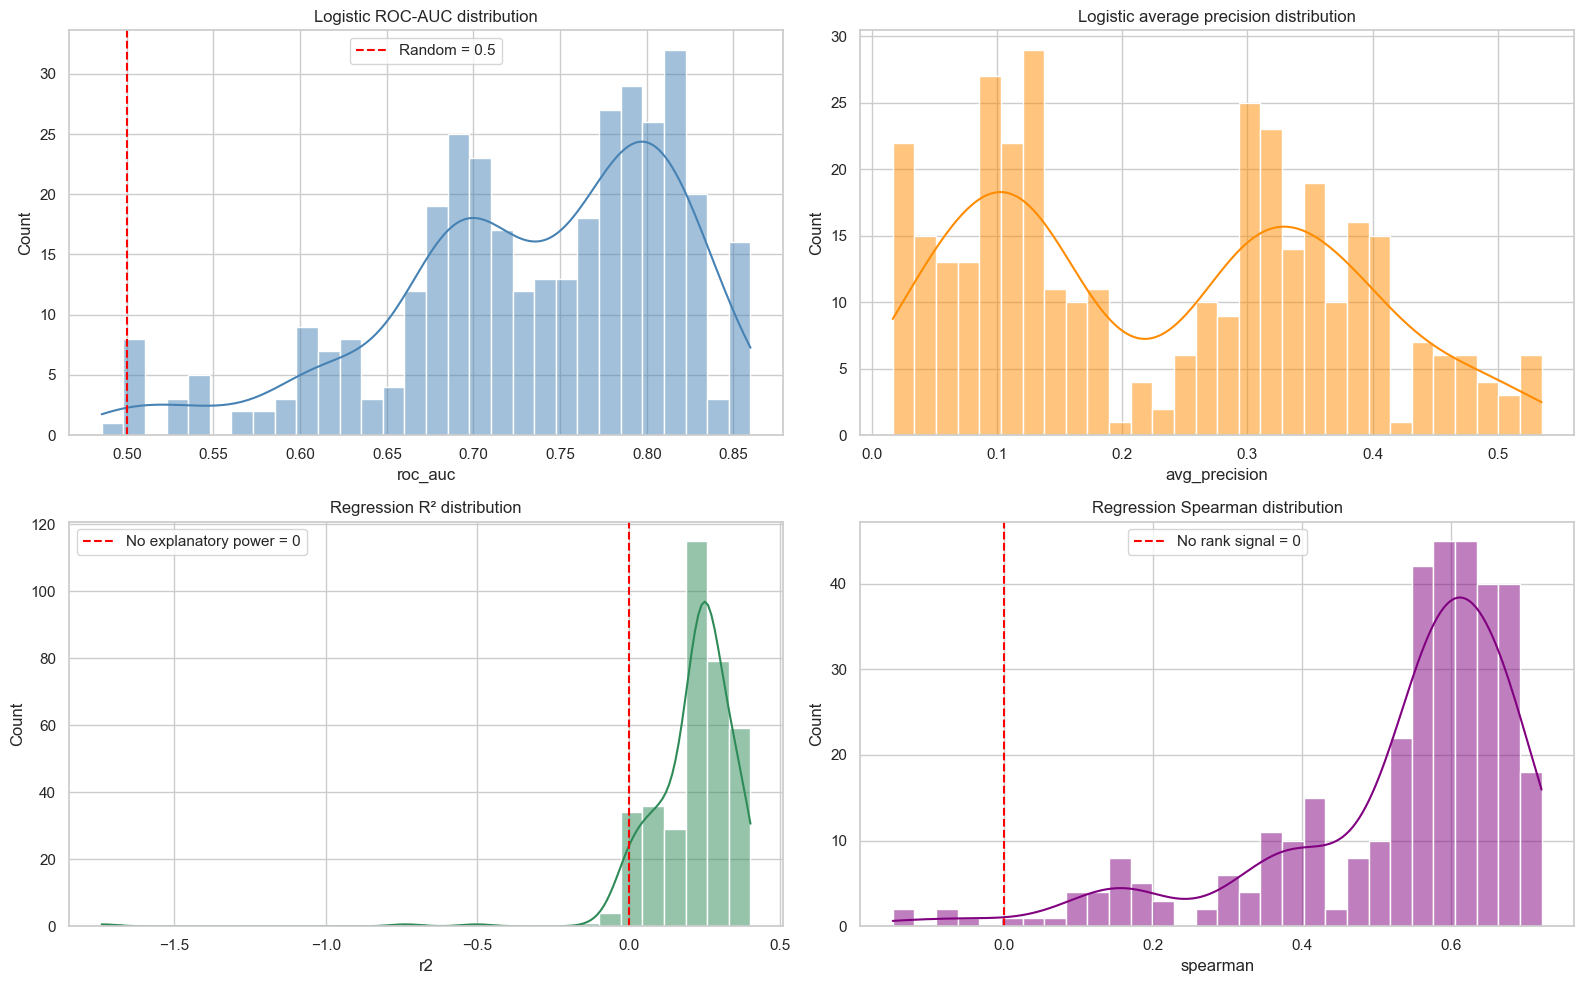

Logistic metric summary


,roc_auc,avg_precision
count,360.0000,360.0000
mean,0.7346,0.2312
std,0.0833,0.1425
min,0.4855,0.0168
25%,0.6865,0.1038
50%,0.7530,0.2426
75%,0.8006,0.3453
max,0.8598,0.5348


Regression metric summary


,r2,rmse,mae,spearman
count,360.0000,360.0000,360.0000,352.0000
mean,0.2099,0.3264,0.2419,0.5306
std,0.1634,0.0482,0.0418,0.1699
min,-1.7391,0.1864,0.1209,-0.1501
25%,0.1436,0.2971,0.2191,0.4871
50%,0.2414,0.3315,0.2440,0.5845
75%,0.2862,0.3540,0.2652,0.6400
max,0.4012,0.4729,0.3850,0.7216


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(logistic['roc_auc'].dropna(), bins=30, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].axvline(0.5, color='red', linestyle='--', label='Random = 0.5')
axes[0, 0].set_title('Logistic ROC-AUC distribution')
axes[0, 0].legend()

sns.histplot(logistic['avg_precision'].dropna(), bins=30, kde=True, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Logistic average precision distribution')

sns.histplot(regression['r2'].dropna(), bins=30, kde=True, ax=axes[1, 0], color='seagreen')
axes[1, 0].axvline(0, color='red', linestyle='--', label='No explanatory power = 0')
axes[1, 0].set_title('Regression R² distribution')
axes[1, 0].legend()

sns.histplot(regression['spearman'].dropna(), bins=30, kde=True, ax=axes[1, 1], color='purple')
axes[1, 1].axvline(0, color='red', linestyle='--', label='No rank signal = 0')
axes[1, 1].set_title('Regression Spearman distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print('Logistic metric summary')
display(logistic[['roc_auc', 'avg_precision']].describe().round(4))
print('Regression metric summary')
display(regression[['r2', 'rmse', 'mae', 'spearman']].describe().round(4))

---
## 3. Heatmaps: model quality by slice value

These heatmaps show every variant against each slice value. Rows are football contexts; columns are model variants.

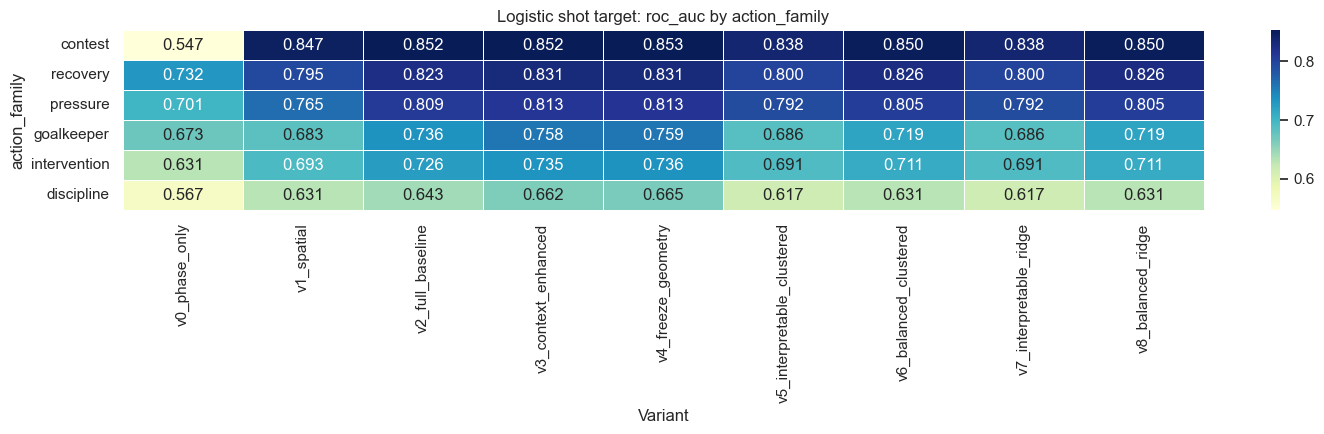

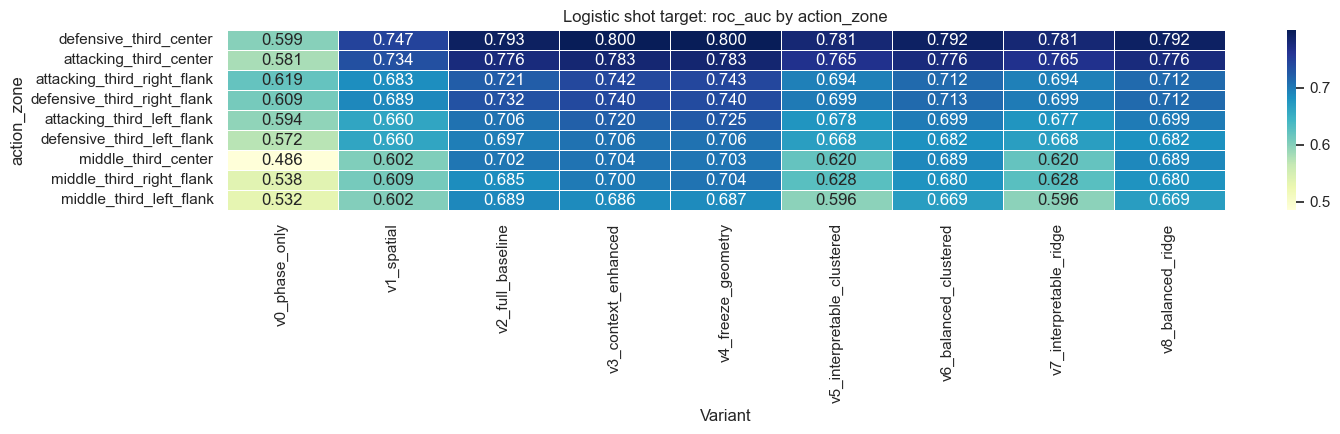

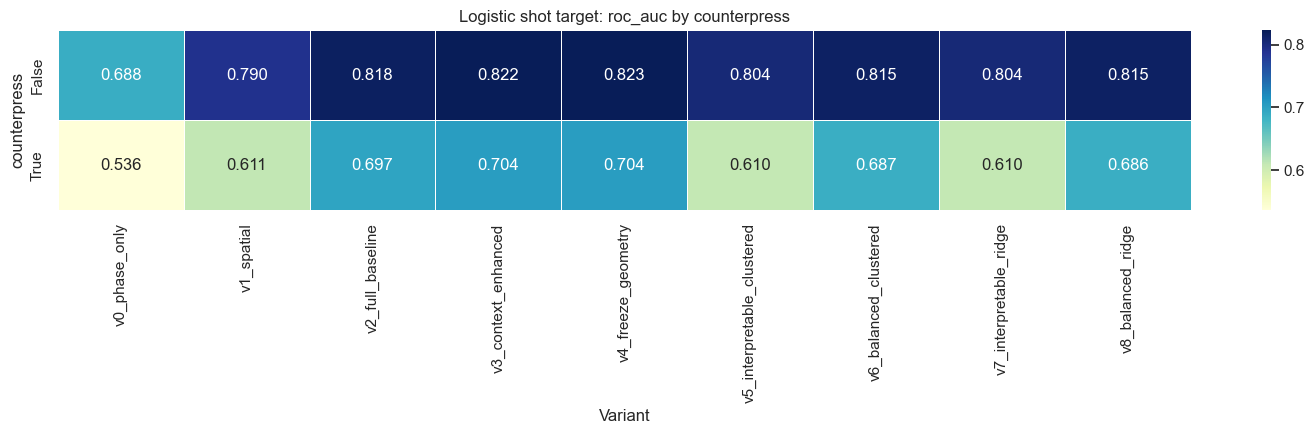

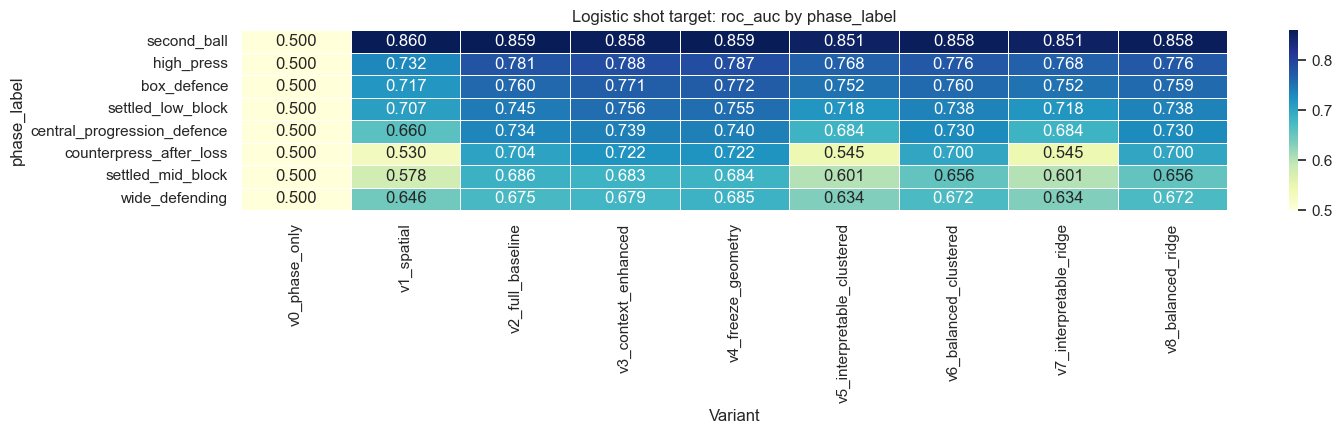

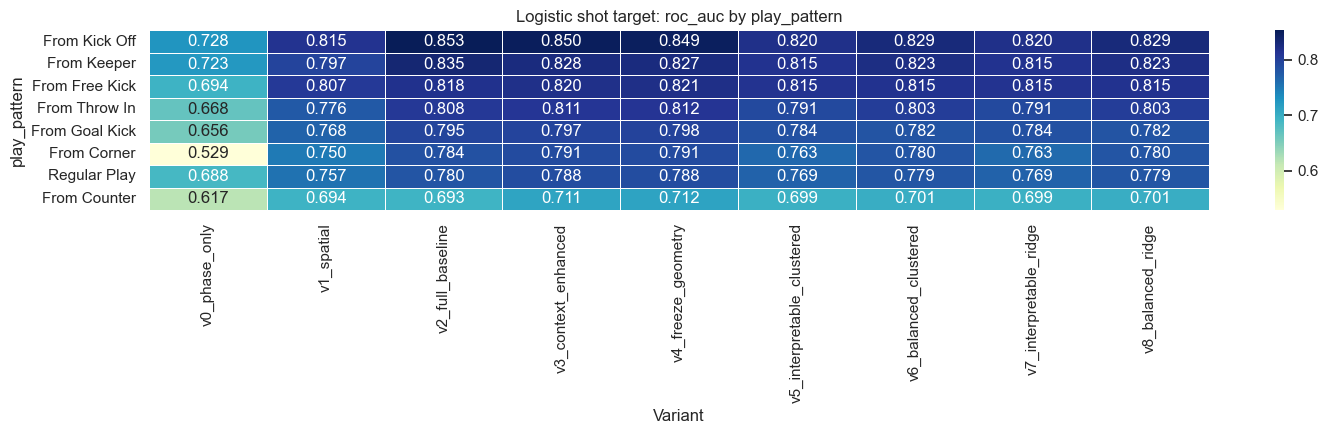

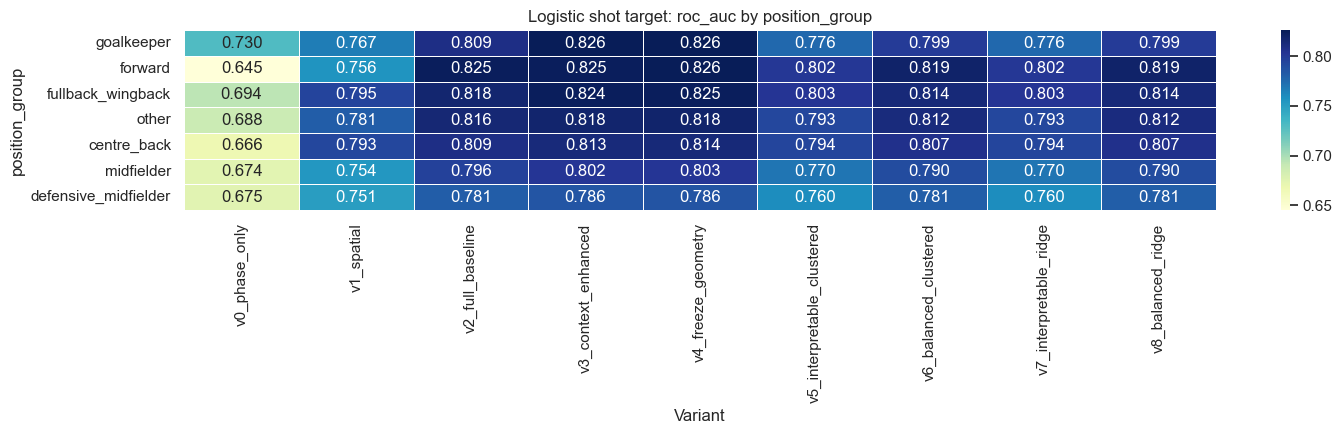

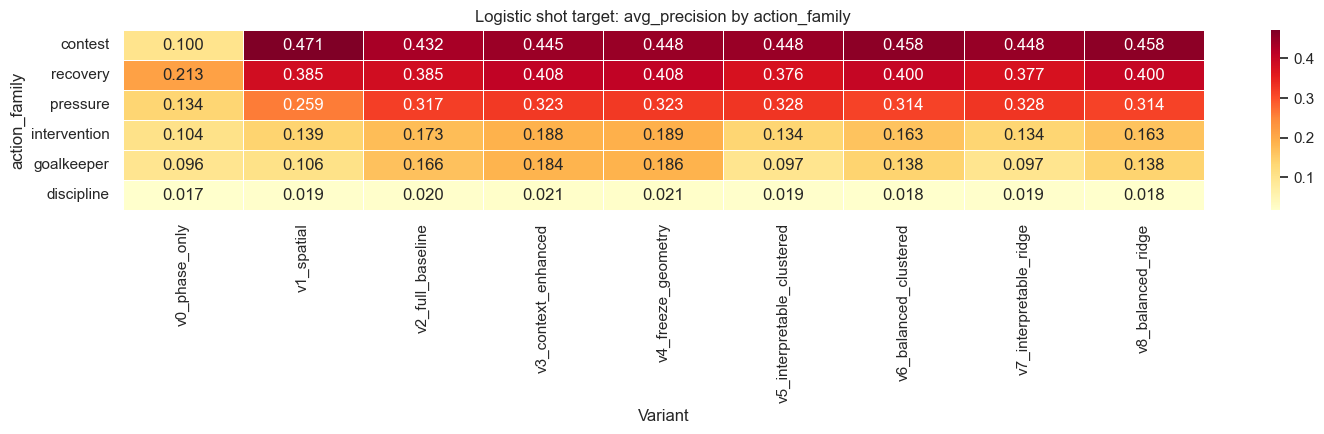

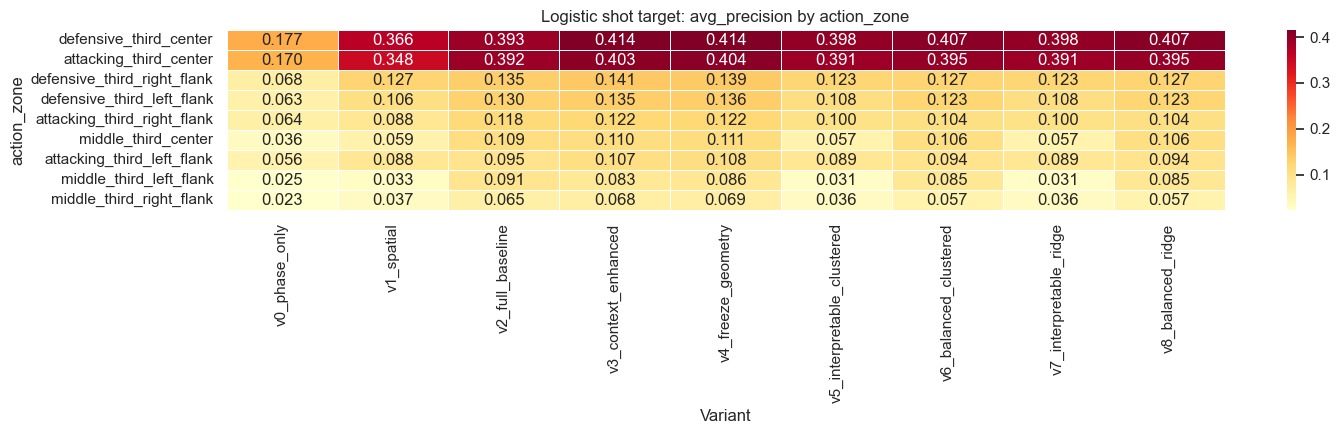

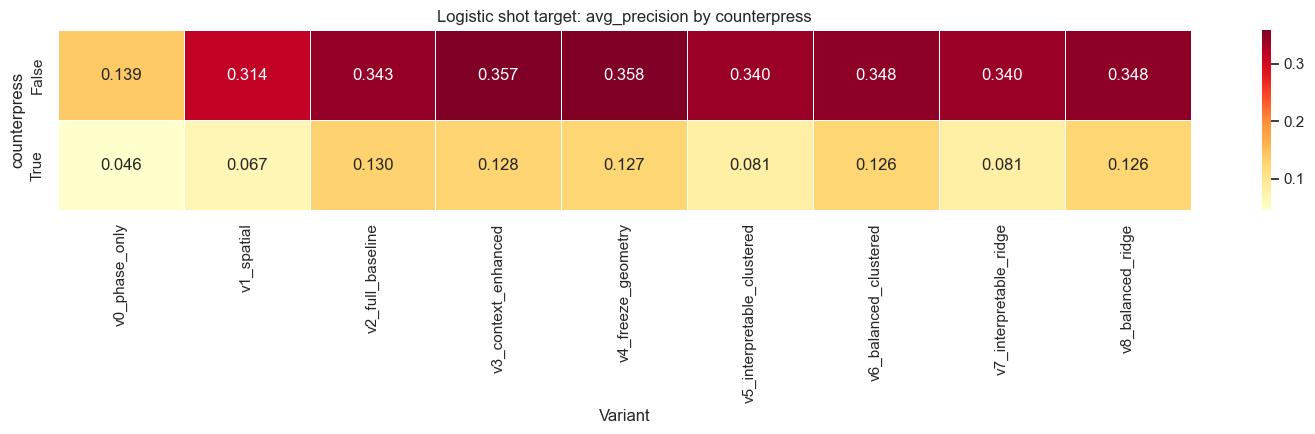

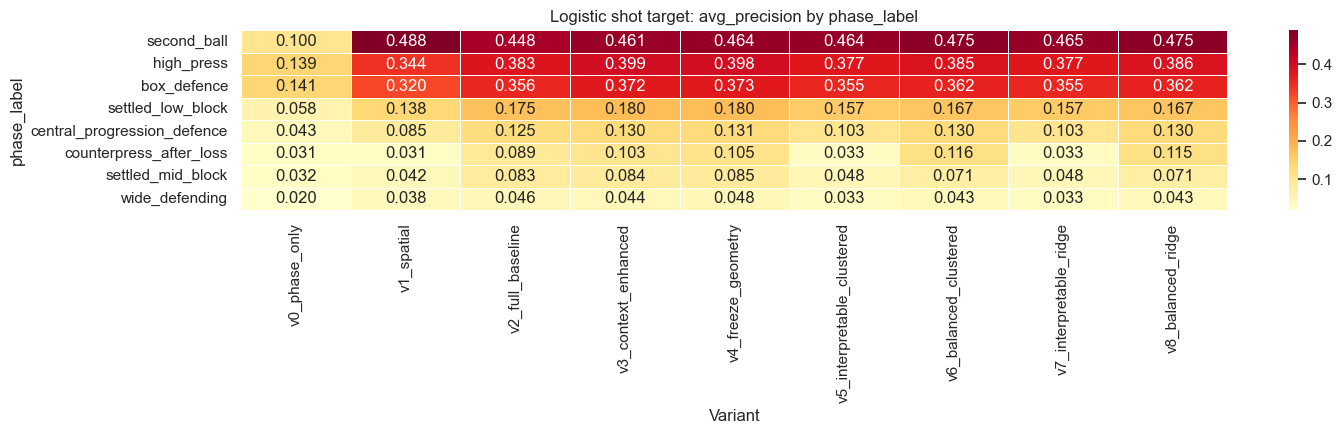

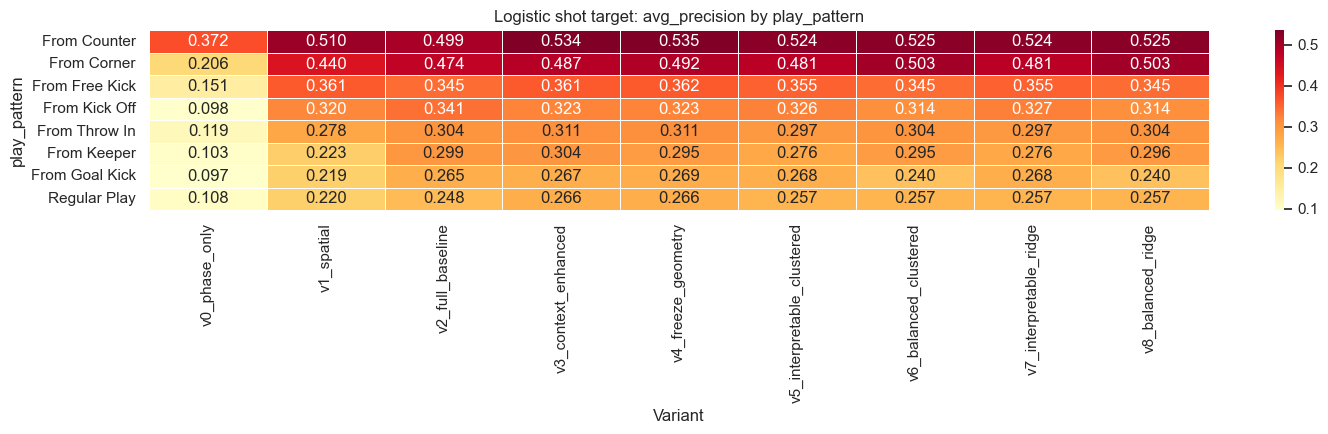

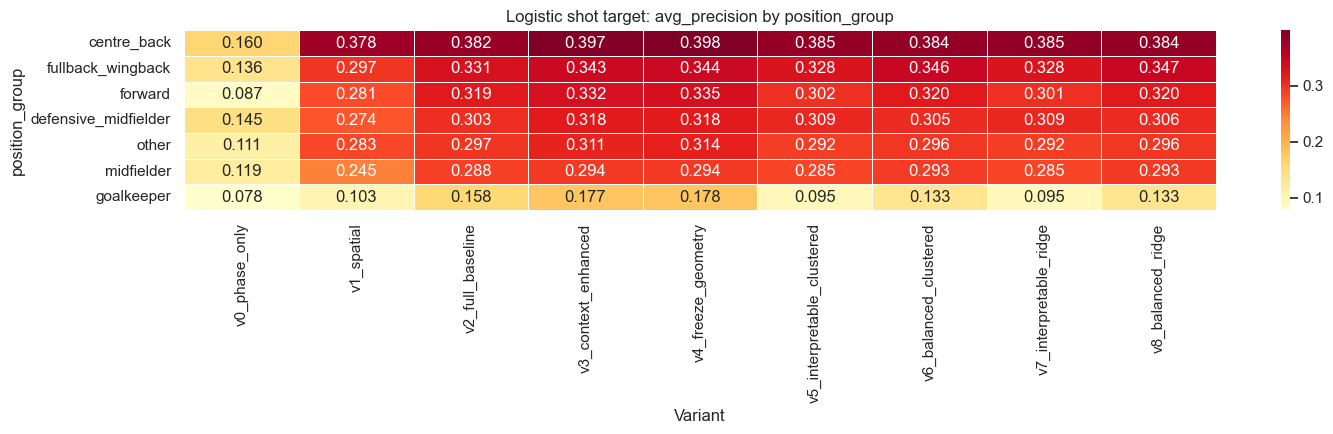

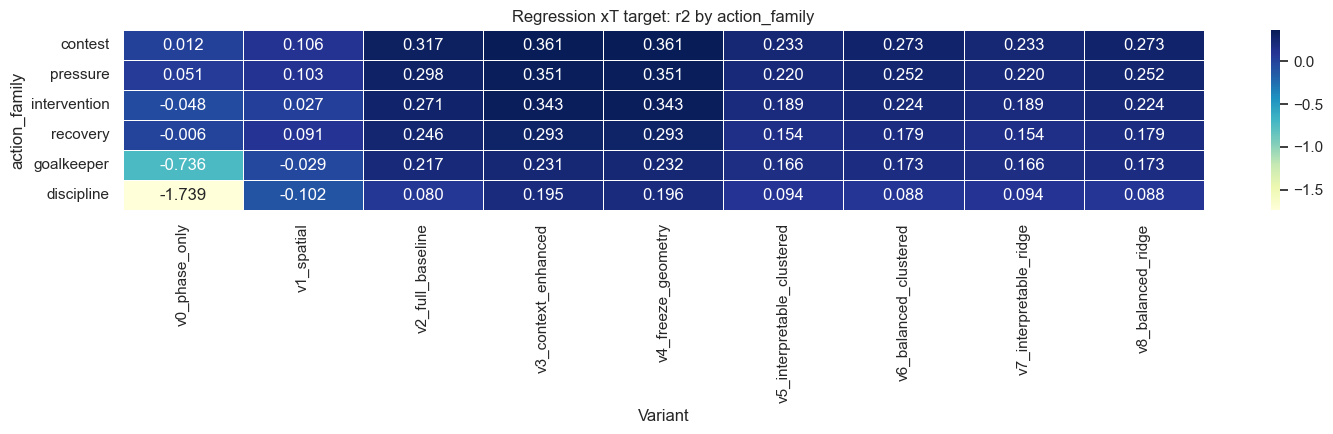

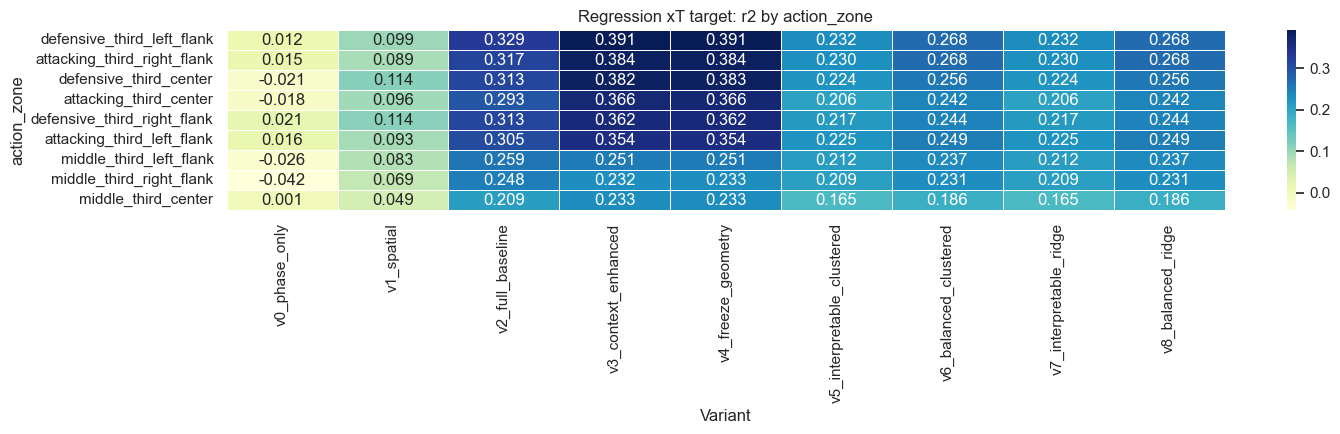

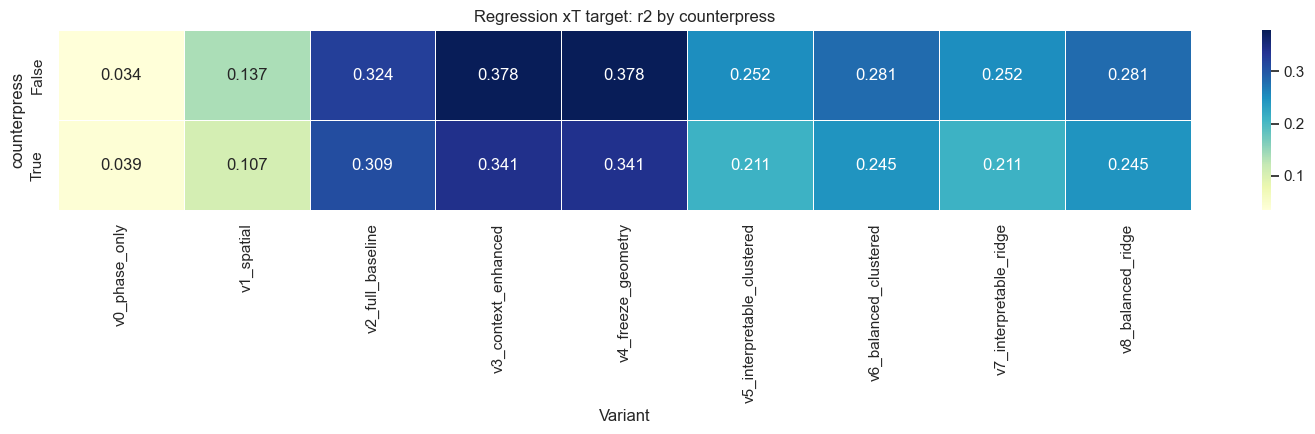

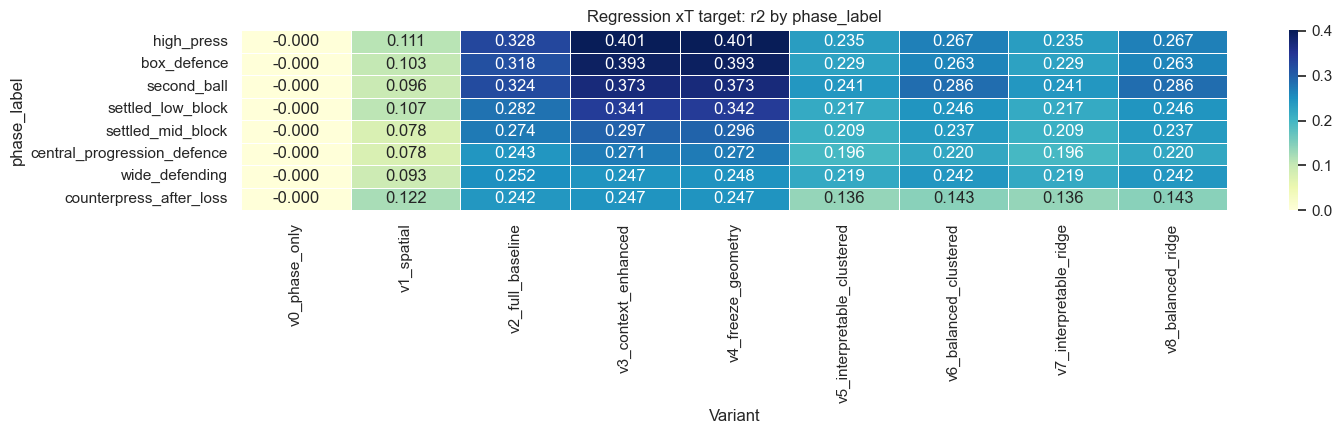

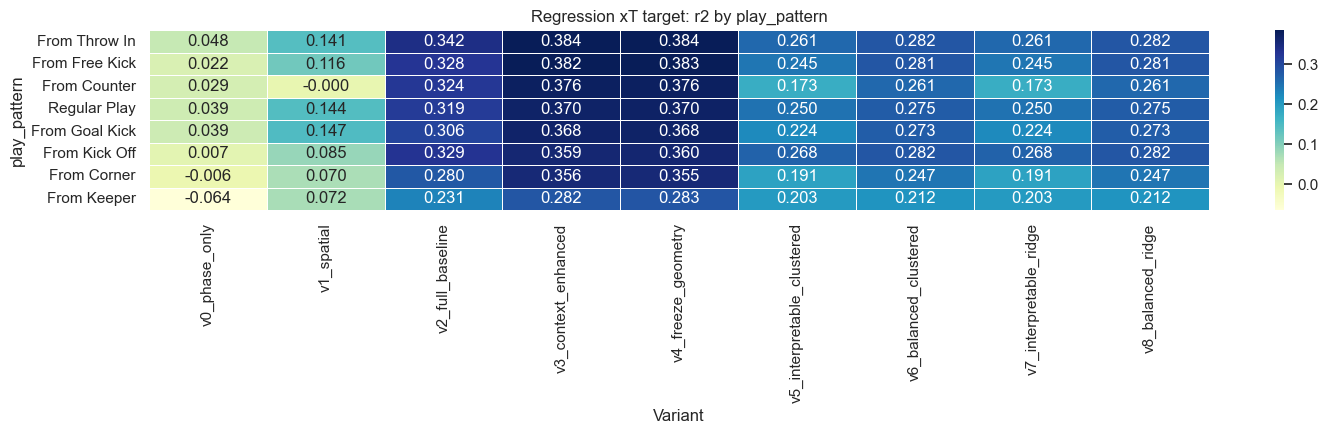

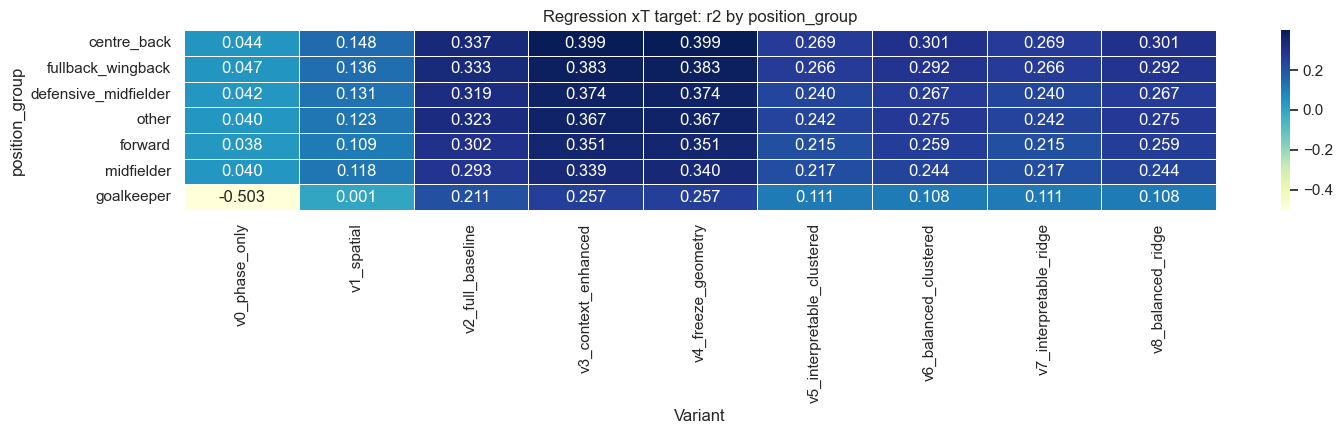

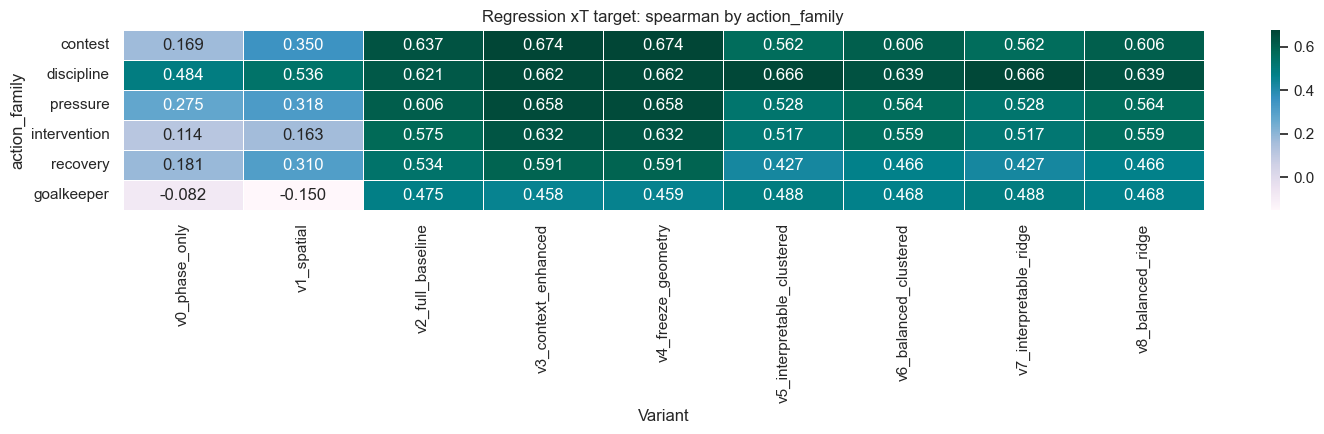

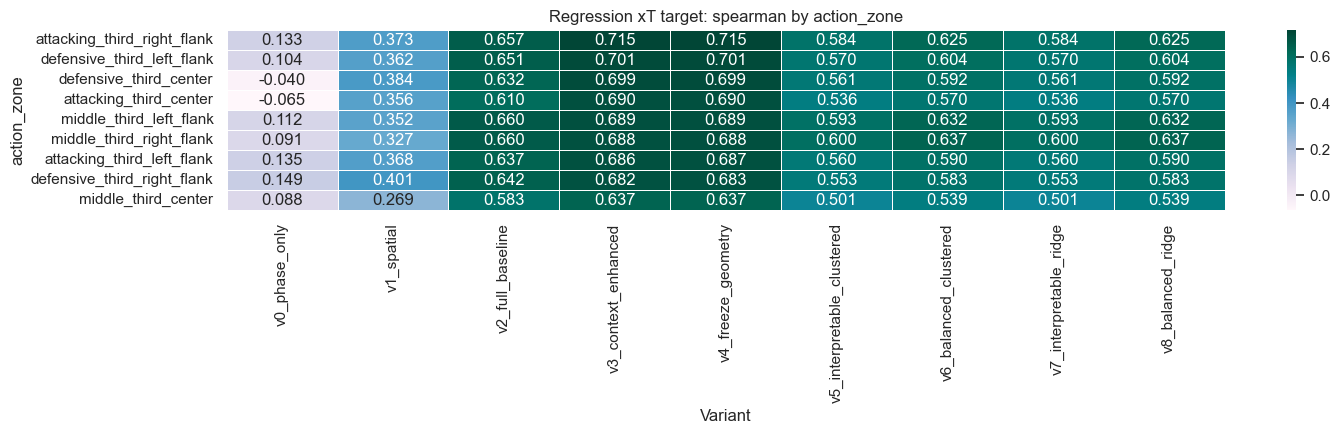

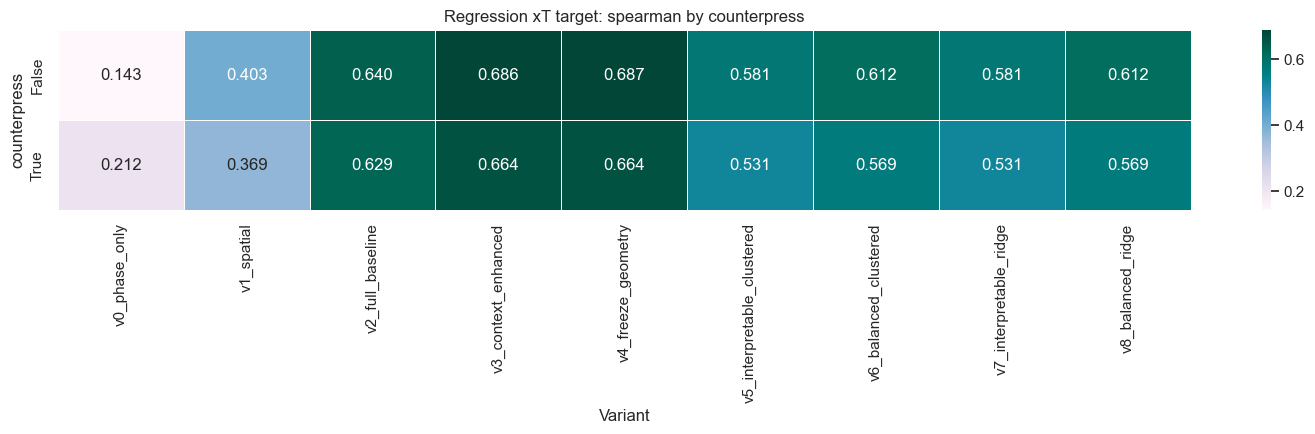

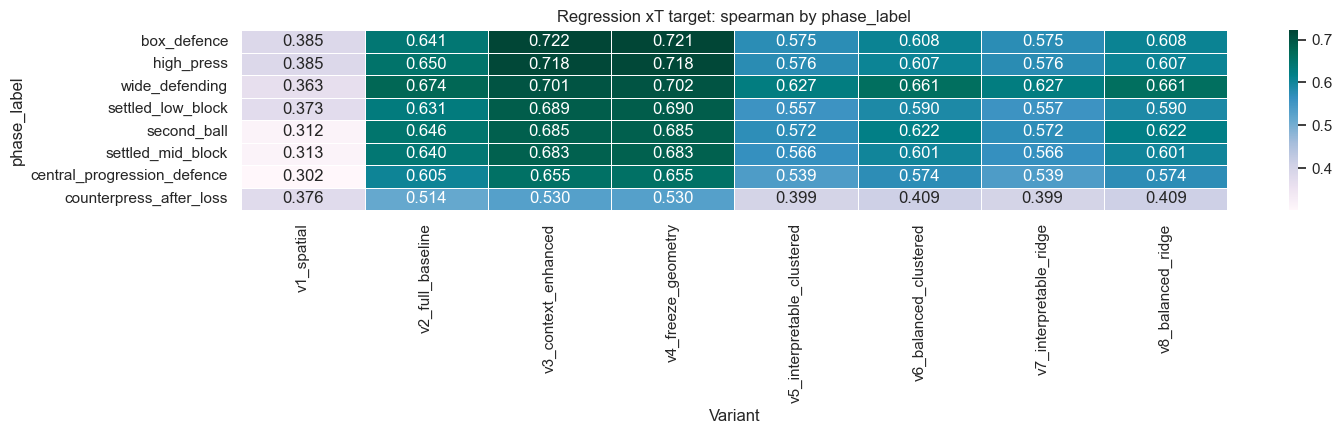

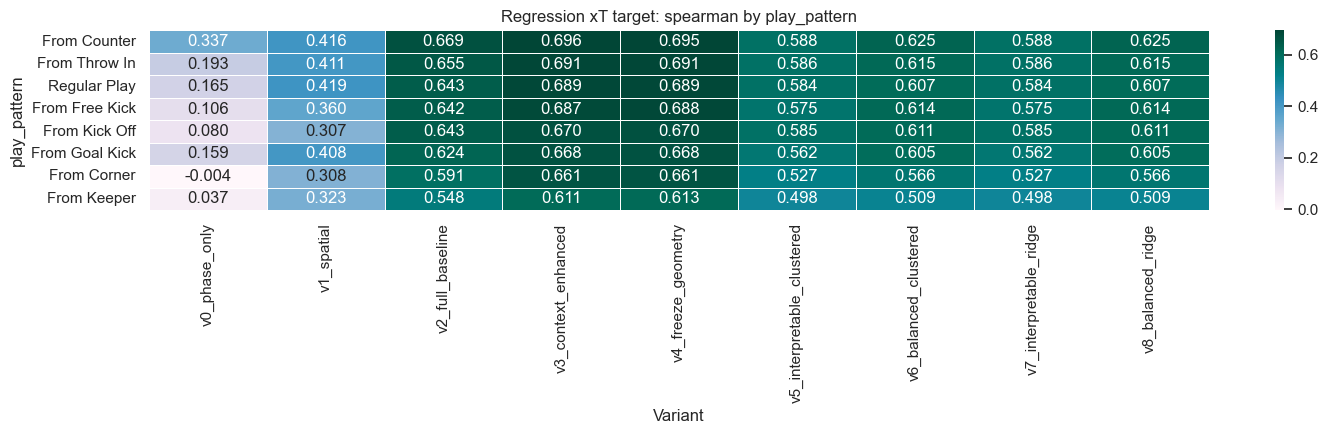

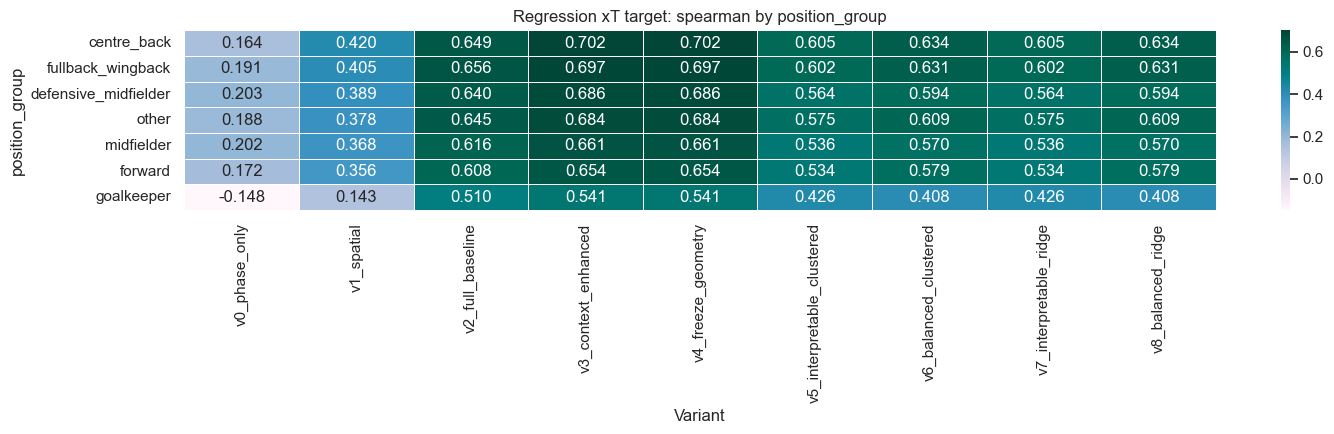

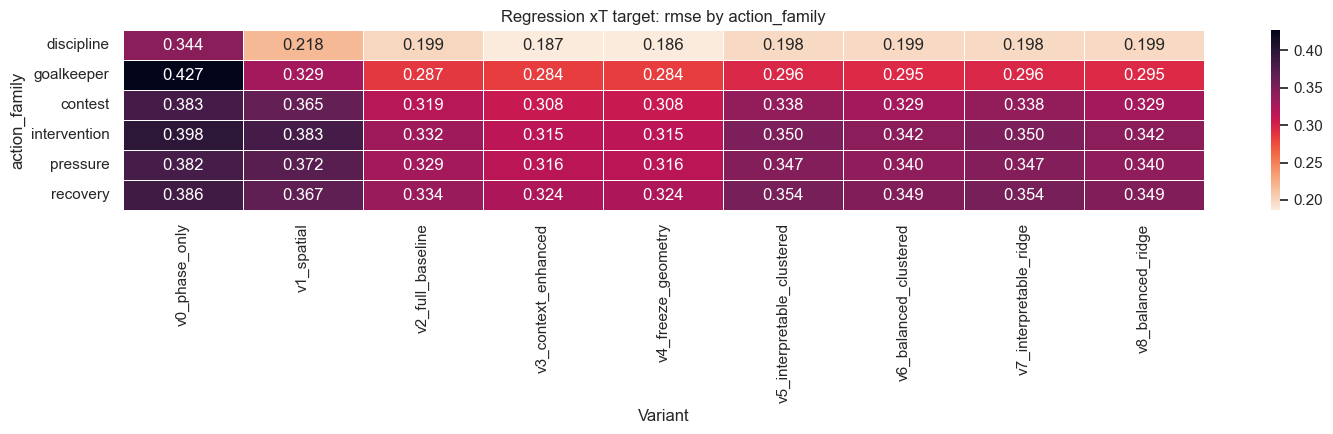

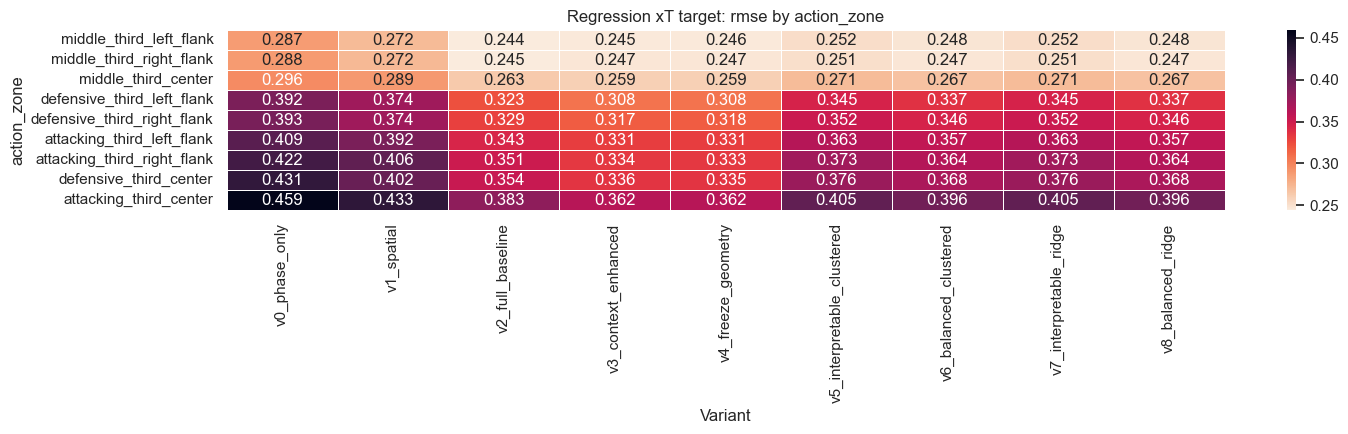

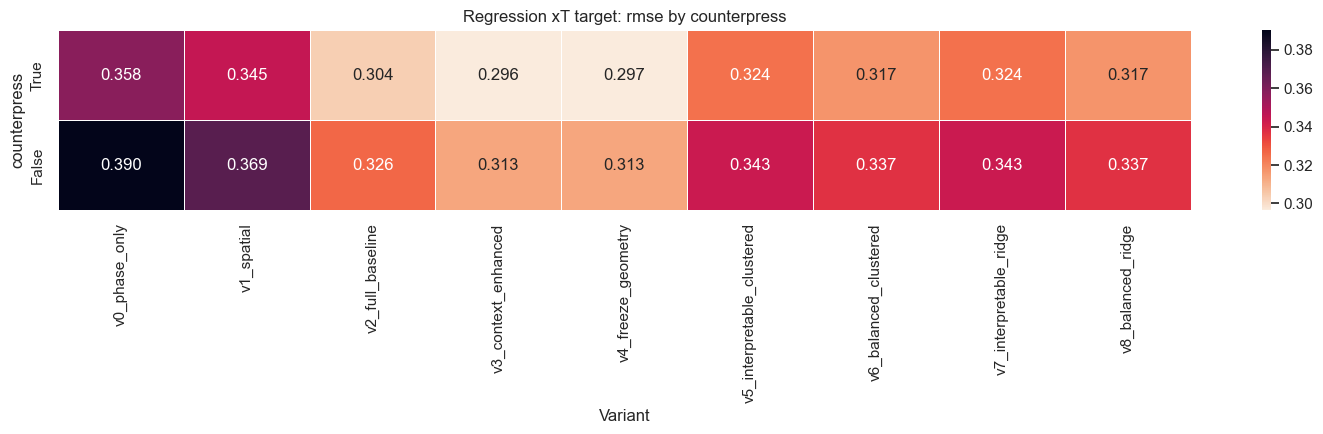

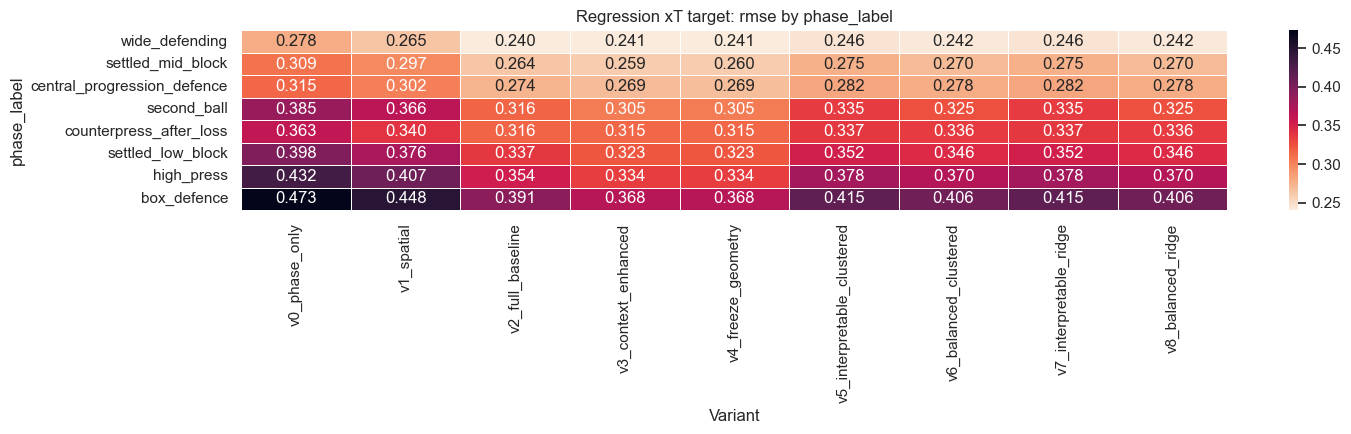

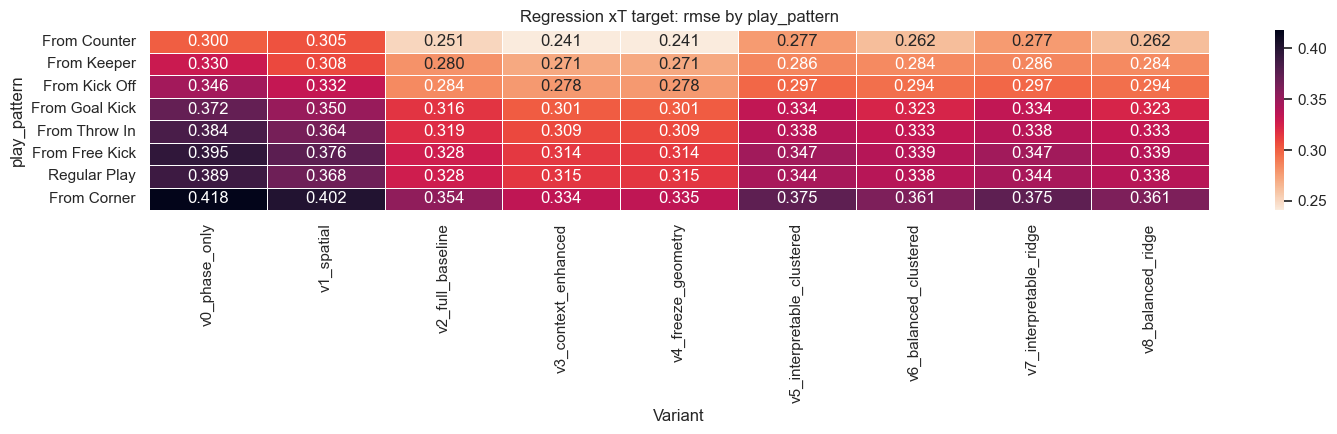

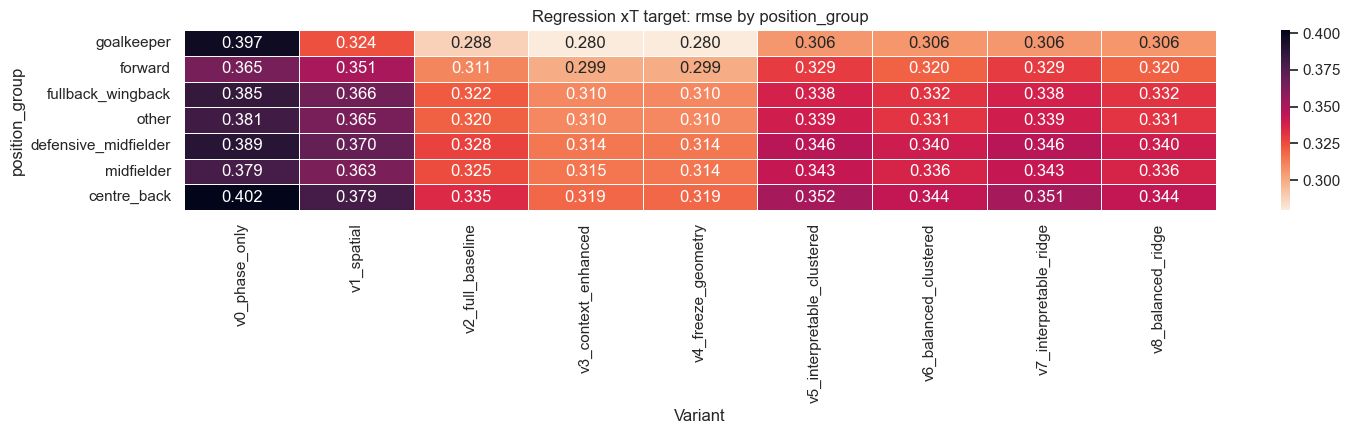

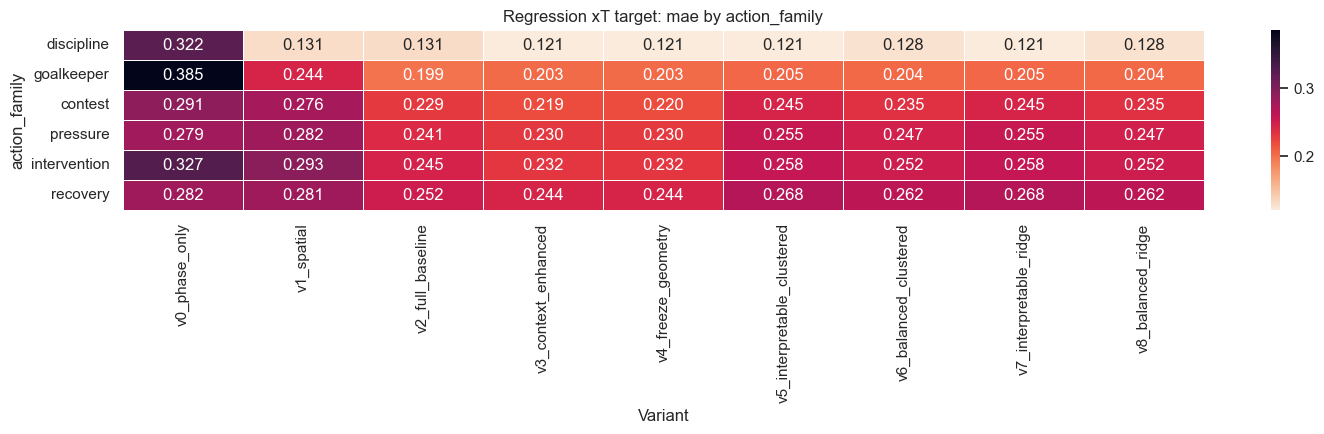

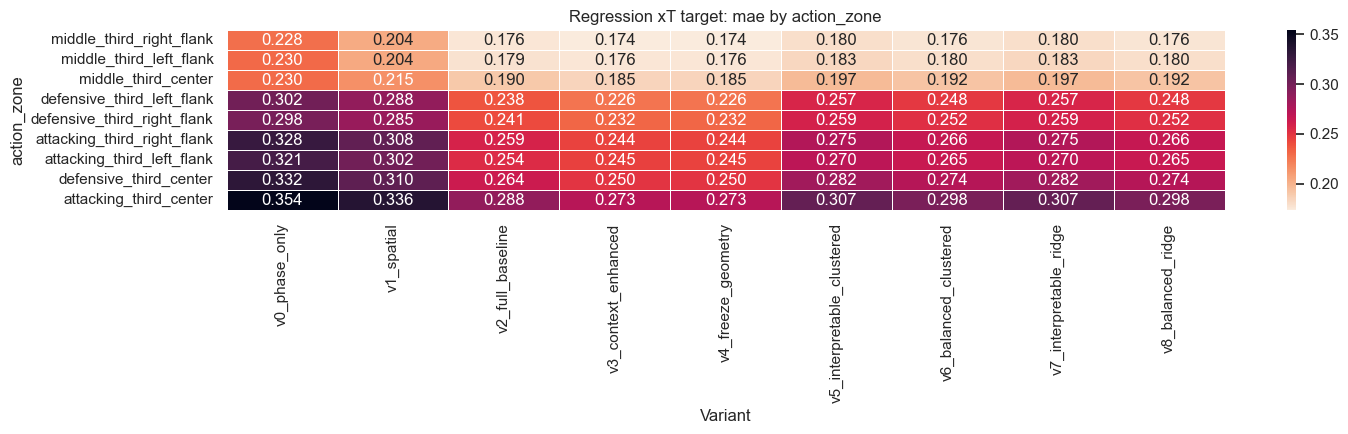

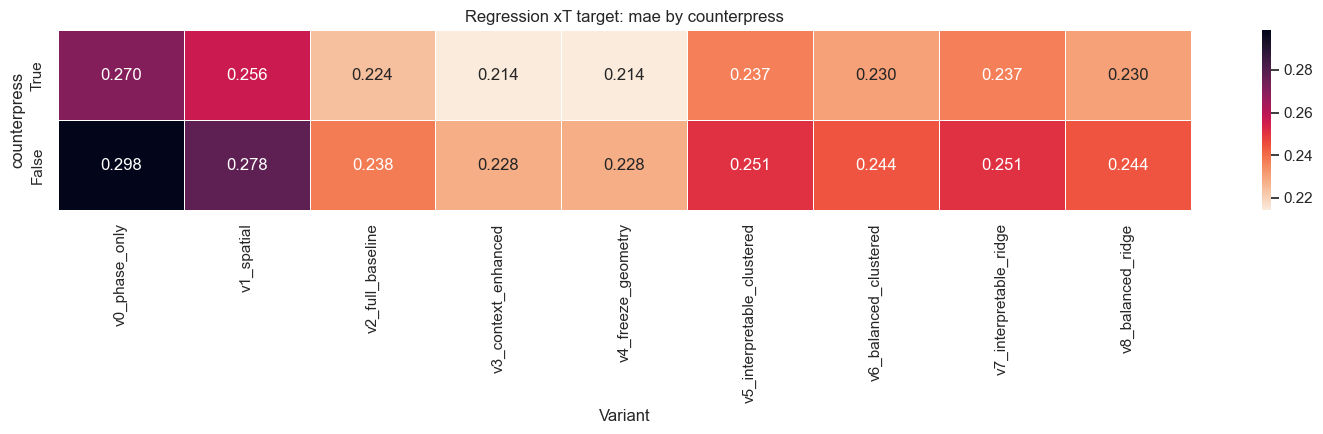

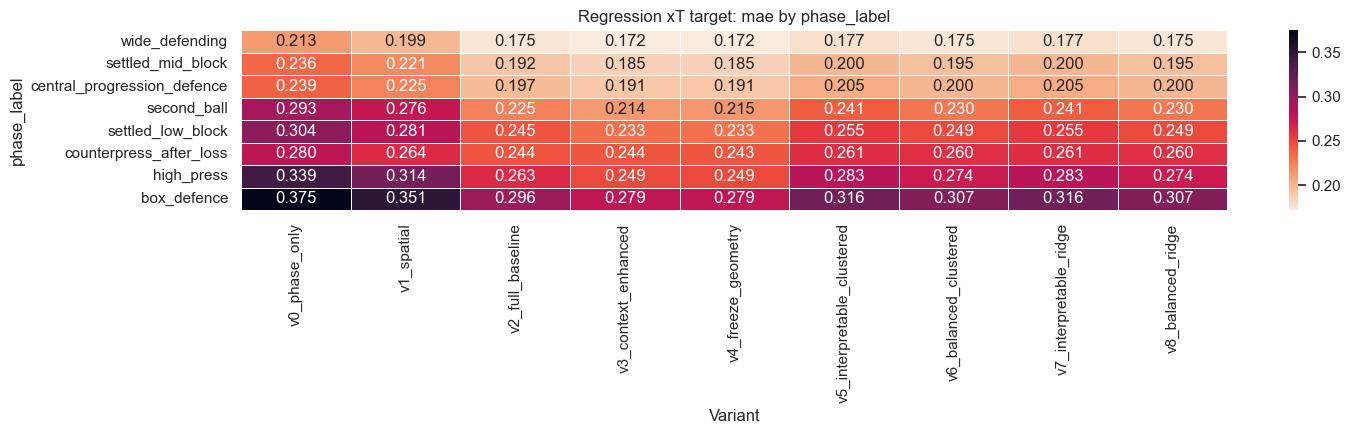

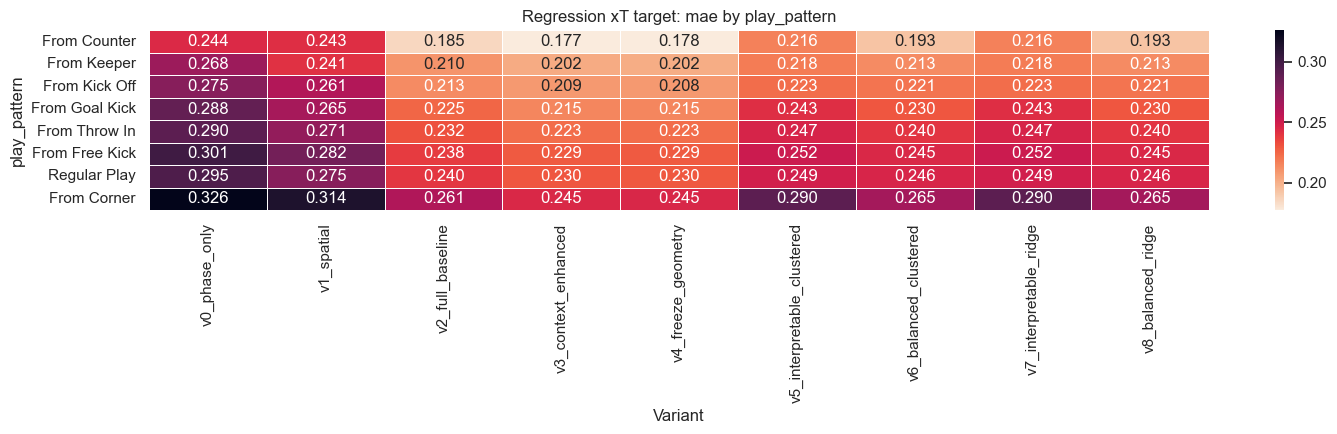

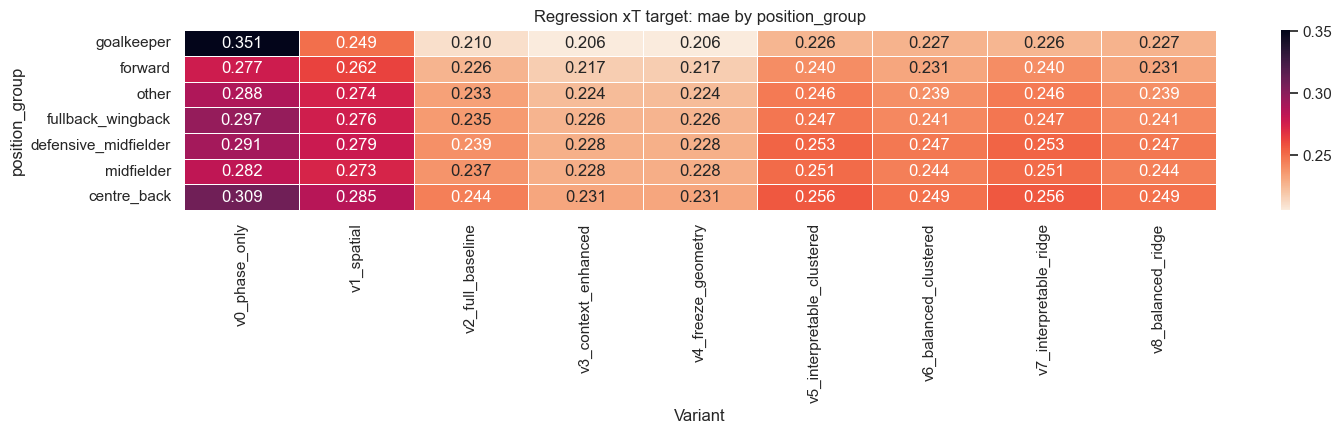

In [4]:
def metric_heatmaps(
    df: pd.DataFrame,
    metric: str,
    title_prefix: str,
    cmap: str,
    higher_is_better: bool = True,
    max_values: int = 45,
) -> None:
    for slice_col in sorted(df['slice_col'].unique()):
        sub = df[df['slice_col'] == slice_col].copy()
        if sub.empty:
            continue
        if sub['slice_value'].nunique() > max_values:
            order = (
                sub.groupby('slice_value')[metric]
                .max()
                .sort_values(ascending=not higher_is_better)
                .head(max_values)
                .index
            )
            sub = sub[sub['slice_value'].isin(order)]

        pivot = sub.pivot_table(index='slice_value', columns='variant', values=metric, aggfunc='mean')
        sort_score = pivot.max(axis=1) if higher_is_better else pivot.min(axis=1)
        pivot = pivot.loc[sort_score.sort_values(ascending=not higher_is_better).index]

        fig_height = max(4.5, min(18, 0.35 * len(pivot)))
        fig, ax = plt.subplots(figsize=(15, fig_height))
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap, linewidths=0.4, ax=ax)
        ax.set_title(f'{title_prefix}: {metric} by {slice_col}')
        ax.set_xlabel('Variant')
        ax.set_ylabel(slice_col)
        plt.tight_layout()
        plt.show()

metric_heatmaps(logistic, 'roc_auc', 'Logistic shot target', 'YlGnBu', higher_is_better=True)
metric_heatmaps(logistic, 'avg_precision', 'Logistic shot target', 'YlOrRd', higher_is_better=True)
metric_heatmaps(regression, 'r2', 'Regression xT target', 'YlGnBu', higher_is_better=True)
metric_heatmaps(regression, 'spearman', 'Regression xT target', 'PuBuGn', higher_is_better=True)
metric_heatmaps(regression, 'rmse', 'Regression xT target', 'rocket_r', higher_is_better=False)
metric_heatmaps(regression, 'mae', 'Regression xT target', 'rocket_r', higher_is_better=False)

---
## 4. Best variant by slice

These are the exported winners for each slice value.

In [5]:
print('Best logistic variant by slice value')
display(best_logistic.sort_values(['slice_col', 'roc_auc'], ascending=[True, False]).reset_index(drop=True).round(4))

print('Best regression variant by slice value')
display(best_regression.sort_values(['slice_col', 'r2'], ascending=[True, False]).reset_index(drop=True).round(4))

Best logistic variant by slice value


,family,variant,slice_col,slice_value,n,roc_auc,avg_precision
0,logistic,v4_freeze_geometry,action_family,contest,6910,0.8526,0.4477
1,logistic,v4_freeze_geometry,action_family,recovery,8932,0.8308,0.4081
2,logistic,v4_freeze_geometry,action_family,pressure,27478,0.8133,0.3228
3,logistic,v4_freeze_geometry,action_family,goalkeeper,1469,0.7586,0.1861
4,logistic,v4_freeze_geometry,action_family,intervention,10105,0.7363,0.1894
5,logistic,v4_freeze_geometry,action_family,discipline,2643,0.6648,0.0213
6,logistic,v4_freeze_geometry,action_zone,defensive_third_center,10187,0.8000,0.4145
7,logistic,v4_freeze_geometry,action_zone,attacking_third_center,12110,0.7833,0.4043
8,logistic,v4_freeze_geometry,action_zone,attacking_third_right_flank,3794,0.7430,0.1221
9,logistic,v3_context_enhanced,action_zone,defensive_third_right_flank,3210,0.7398,0.1409


Best regression variant by slice value


,family,variant,slice_col,slice_value,n,r2,rmse,mae,spearman
0,regression,v3_context_enhanced,action_family,contest,6910,0.3611,0.3083,0.2194,0.6739
1,regression,v4_freeze_geometry,action_family,pressure,27478,0.3511,0.3163,0.2303,0.6581
2,regression,v3_context_enhanced,action_family,intervention,10105,0.3429,0.3151,0.2318,0.6317
3,regression,v4_freeze_geometry,action_family,recovery,8932,0.2933,0.3236,0.2441,0.5915
4,regression,v4_freeze_geometry,action_family,goalkeeper,1469,0.2318,0.2839,0.2031,0.4586
5,regression,v4_freeze_geometry,action_family,discipline,2643,0.1960,0.1864,0.1211,0.6617
6,regression,v4_freeze_geometry,action_zone,defensive_third_left_flank,3477,0.3914,0.3076,0.2262,0.7013
7,regression,v4_freeze_geometry,action_zone,attacking_third_right_flank,3794,0.3842,0.3334,0.2444,0.7150
8,regression,v4_freeze_geometry,action_zone,defensive_third_center,10187,0.3826,0.3354,0.2499,0.6990
9,regression,v4_freeze_geometry,action_zone,attacking_third_center,12110,0.3663,0.3622,0.2728,0.6899


---
## 5. Variant win counts

This answers: *which model keeps winning across football contexts?*

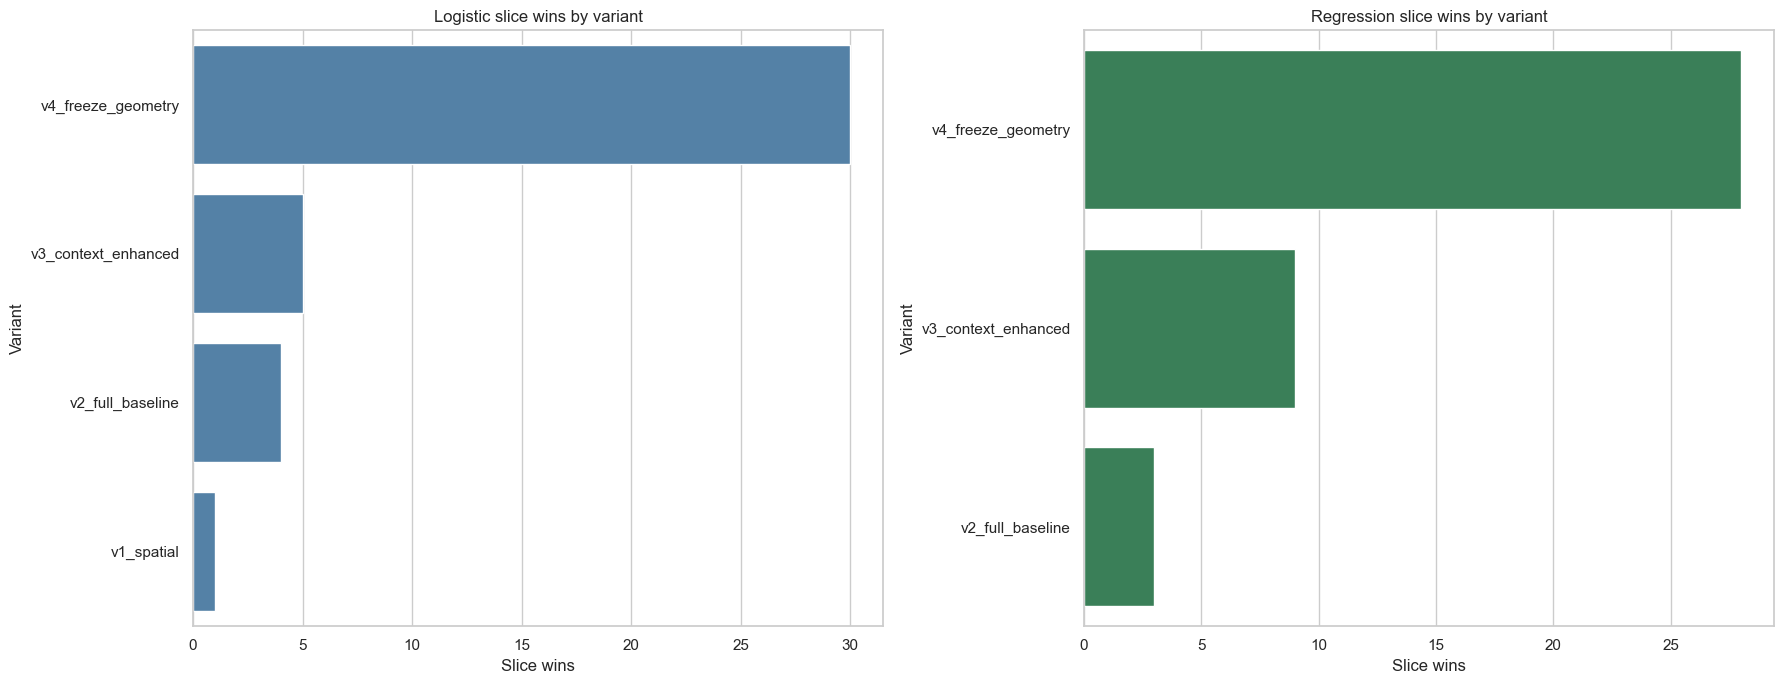

,variant,wins
0,v4_freeze_geometry,30
1,v3_context_enhanced,5
2,v2_full_baseline,4
3,v1_spatial,1


,variant,wins
0,v4_freeze_geometry,28
1,v3_context_enhanced,9
2,v2_full_baseline,3


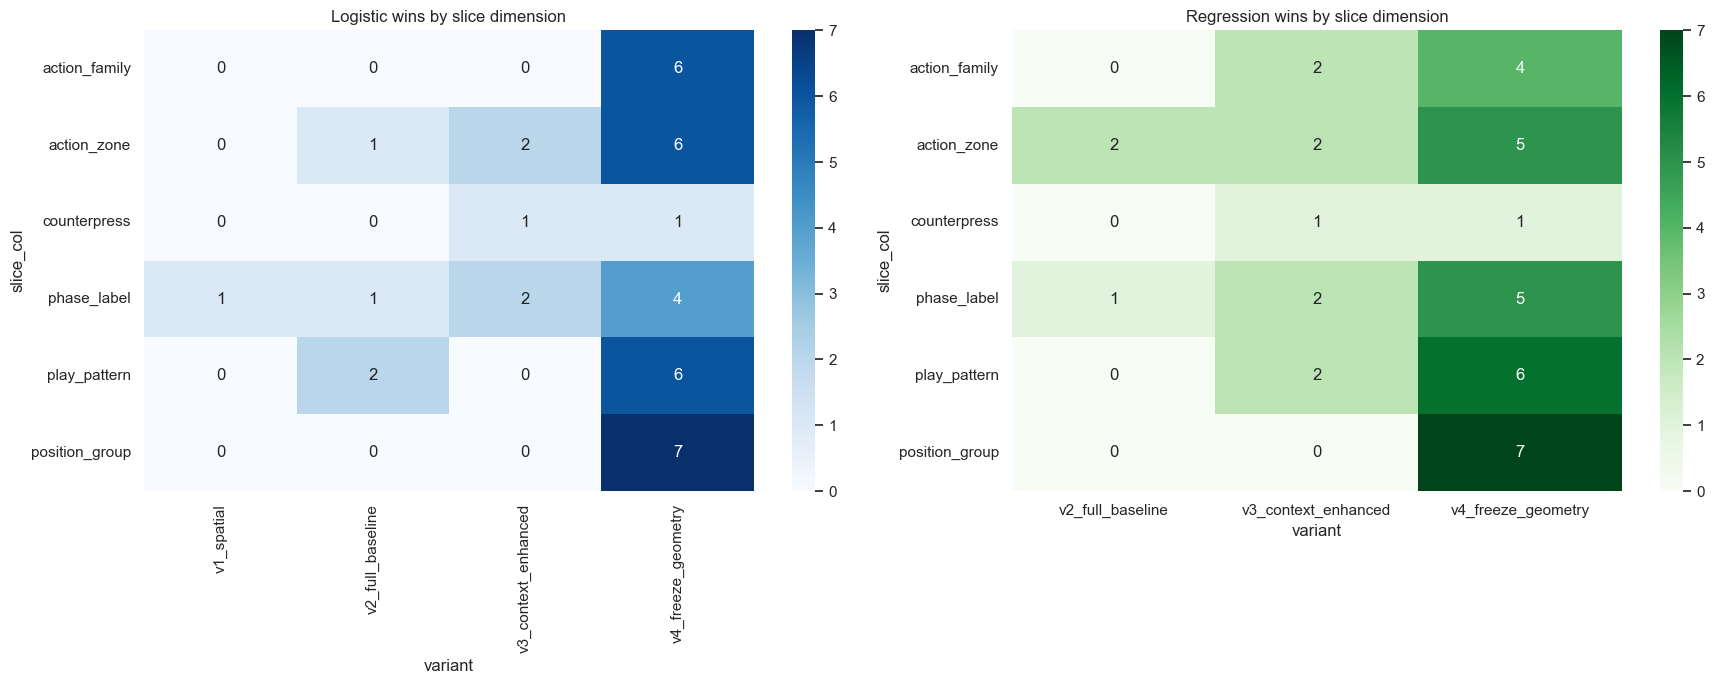

In [6]:
log_wins = best_logistic['variant'].value_counts().rename_axis('variant').reset_index(name='wins')
reg_wins = best_regression['variant'].value_counts().rename_axis('variant').reset_index(name='wins')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.barplot(data=log_wins, y='variant', x='wins', ax=axes[0], color='steelblue')
axes[0].set_title('Logistic slice wins by variant')
axes[0].set_xlabel('Slice wins')
axes[0].set_ylabel('Variant')

sns.barplot(data=reg_wins, y='variant', x='wins', ax=axes[1], color='seagreen')
axes[1].set_title('Regression slice wins by variant')
axes[1].set_xlabel('Slice wins')
axes[1].set_ylabel('Variant')
plt.tight_layout()
plt.show()

display(log_wins)
display(reg_wins)

win_by_dimension_log = pd.crosstab(best_logistic['slice_col'], best_logistic['variant'])
win_by_dimension_reg = pd.crosstab(best_regression['slice_col'], best_regression['variant'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(win_by_dimension_log, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic wins by slice dimension')
sns.heatmap(win_by_dimension_reg, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Regression wins by slice dimension')
plt.tight_layout()
plt.show()

---
## 6. Improvement over baseline model

Baseline is `v0_phase_only`. Positive deltas mean a variant beats the phase-only model in that slice.

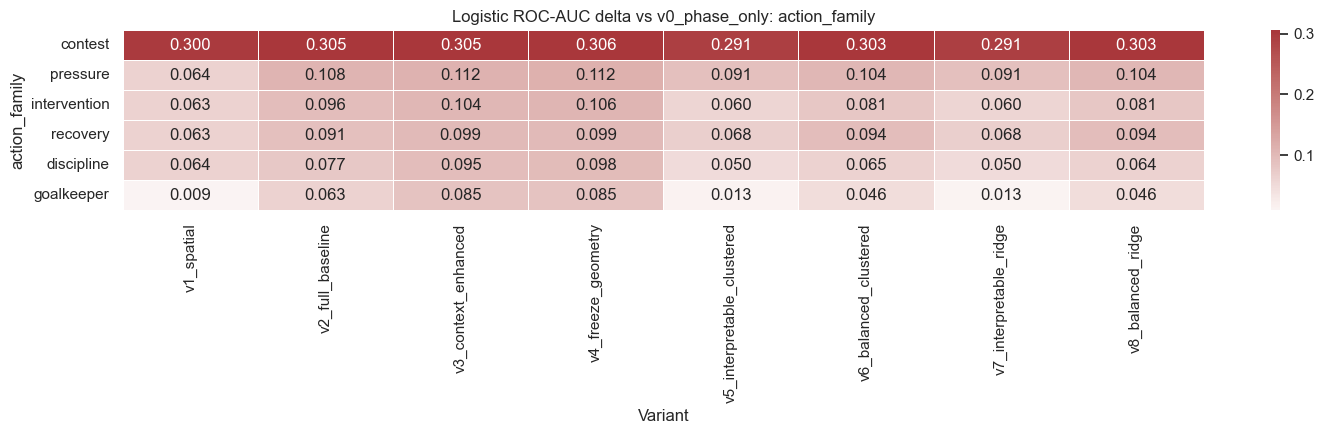

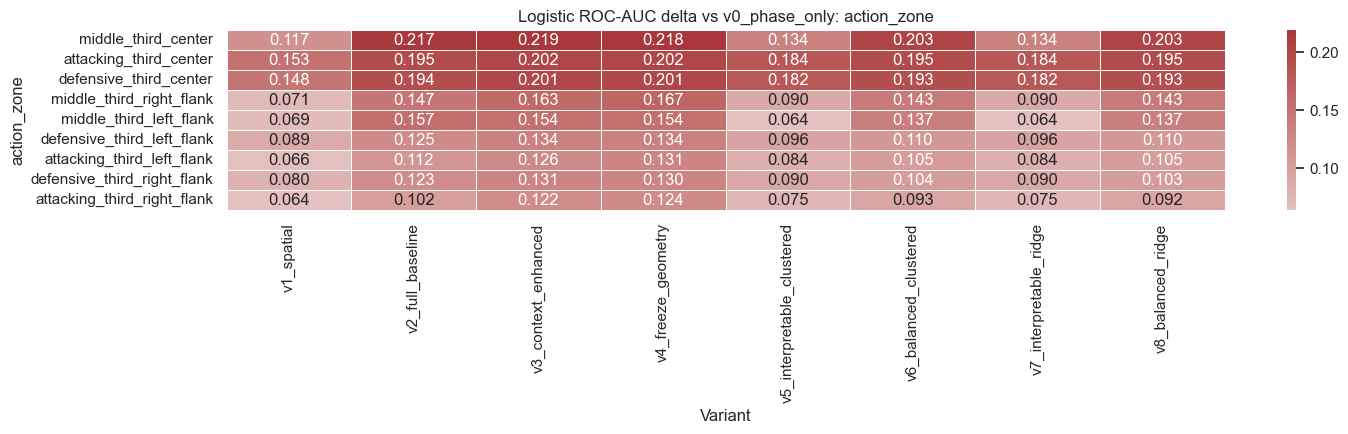

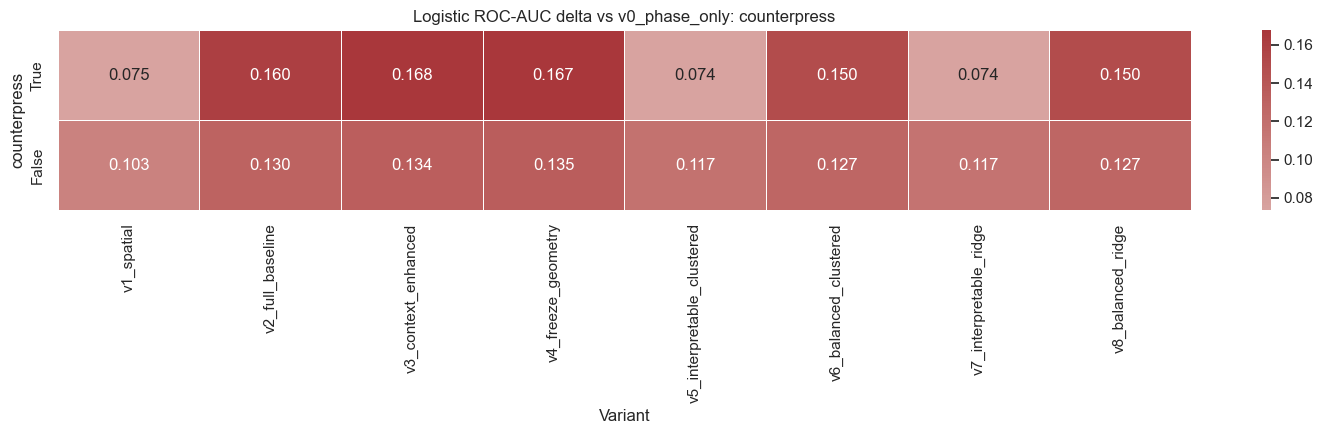

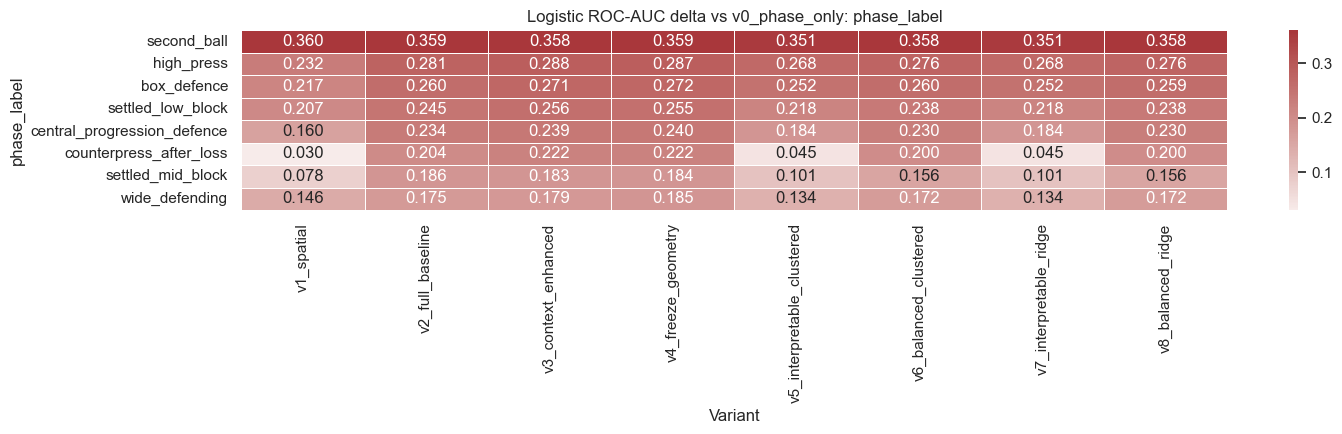

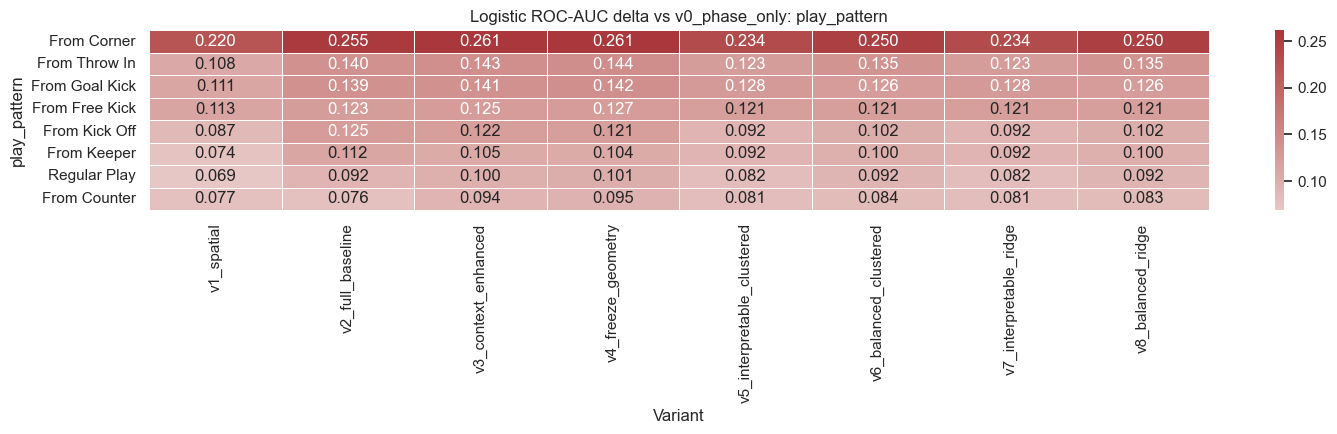

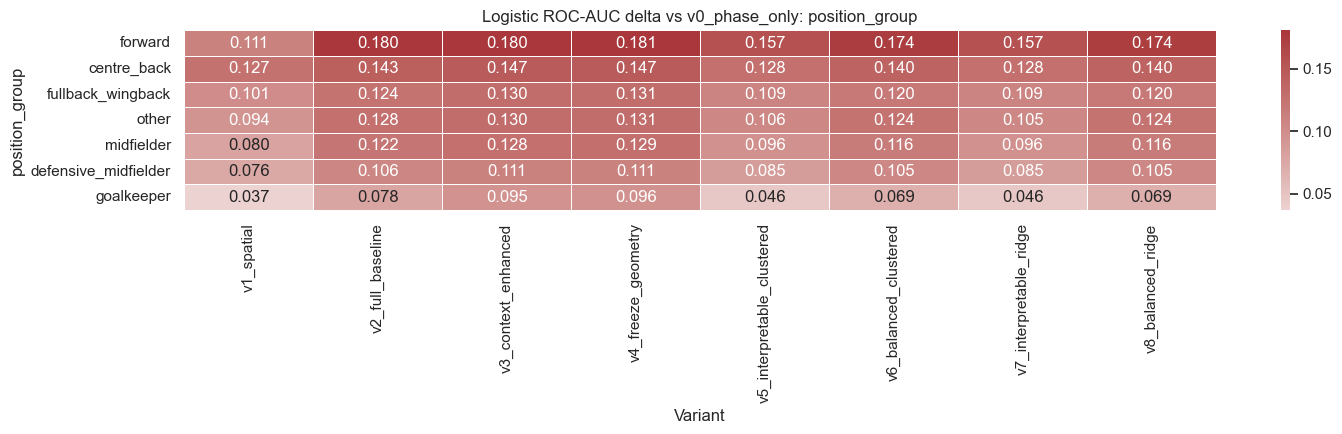

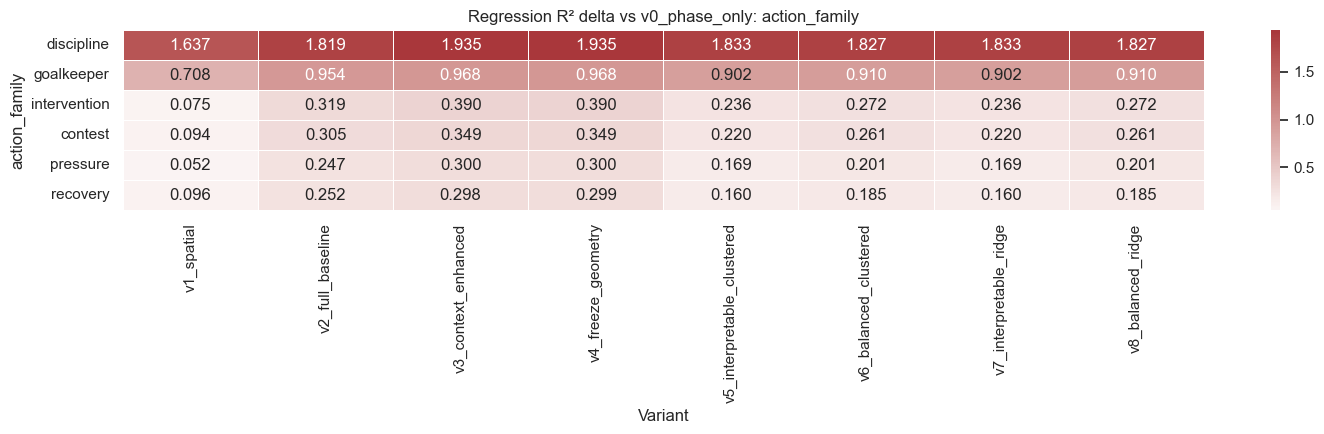

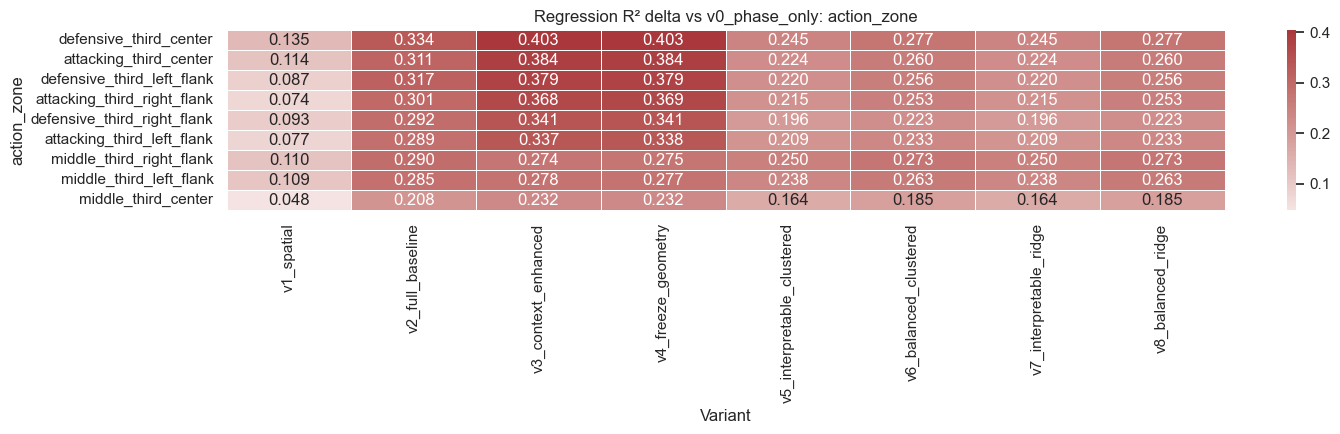

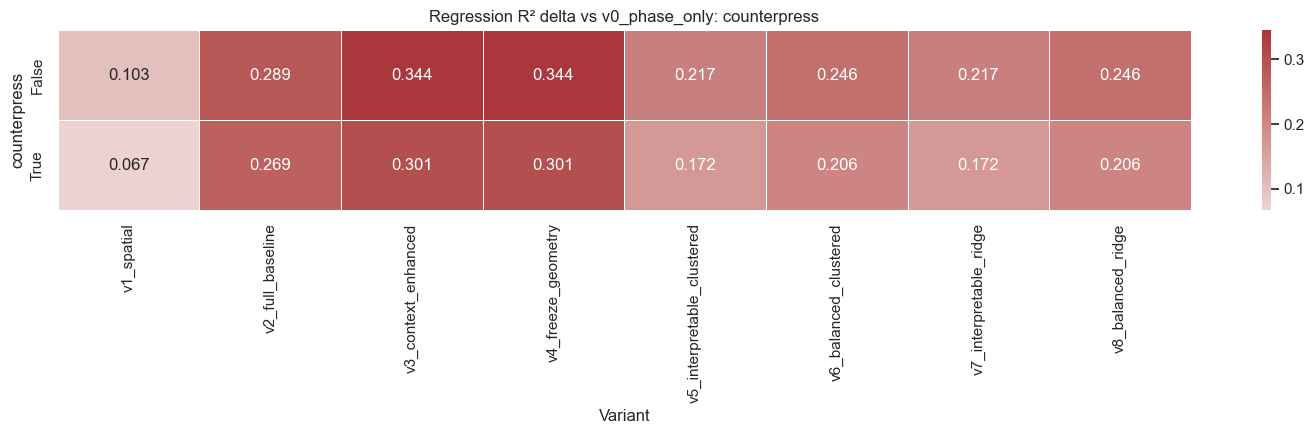

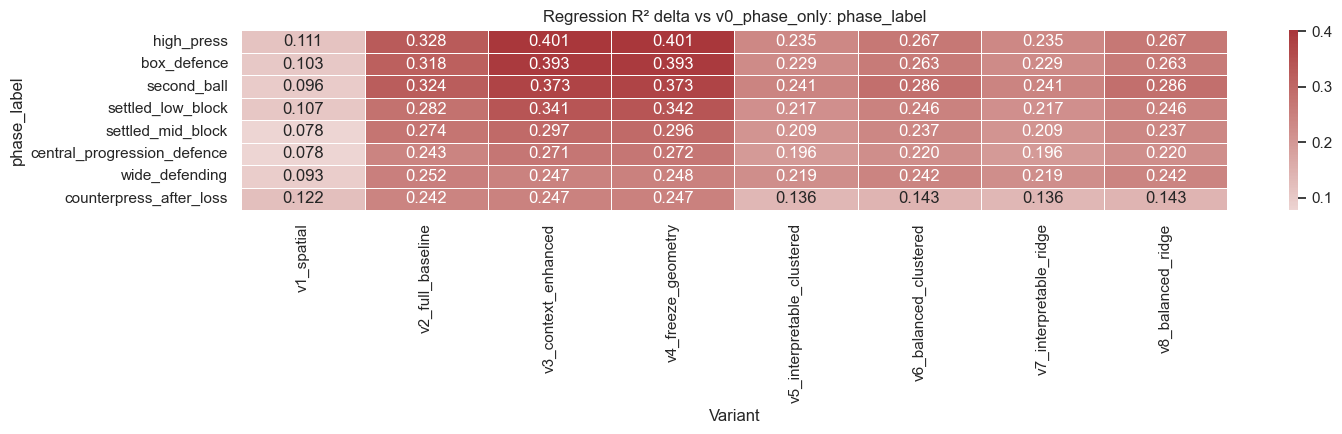

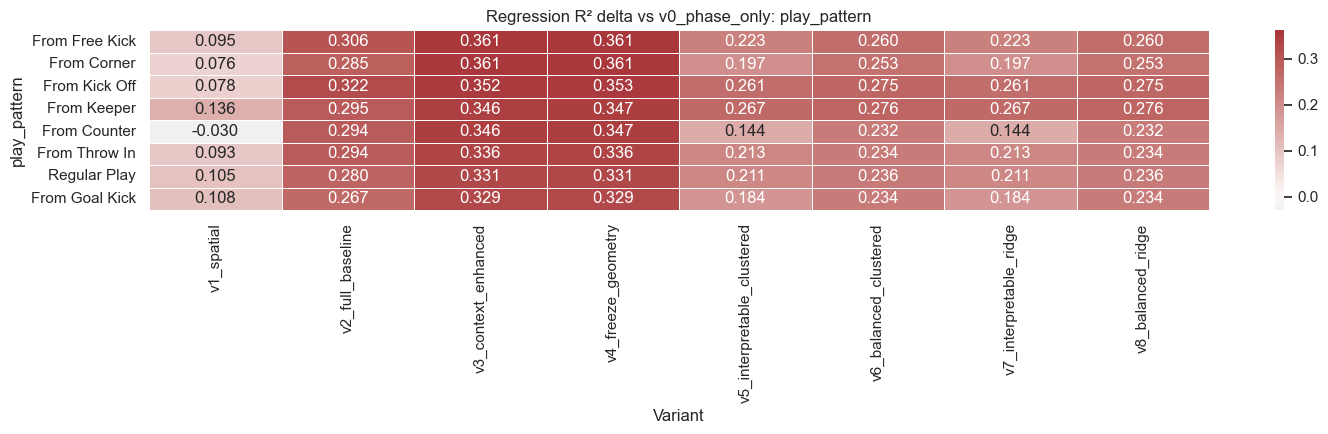

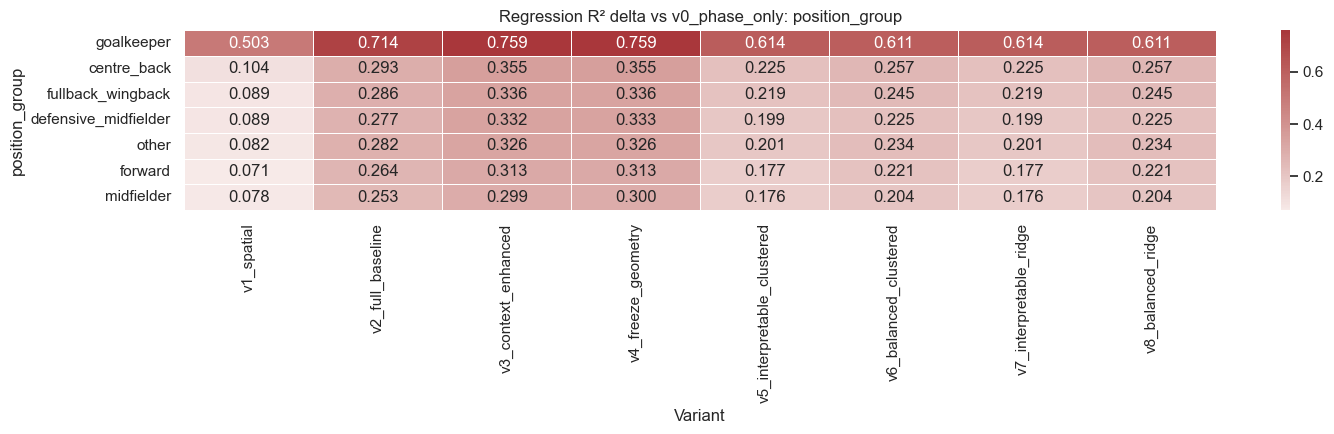

Top logistic improvements over baseline


,family,variant,slice_col,slice_value,n,roc_auc,avg_precision,roc_auc_baseline,roc_auc_delta_vs_baseline
44,logistic,v1_spatial,phase_label,second_ball,6035,0.8598,0.4879,0.500,0.3598
84,logistic,v2_full_baseline,phase_label,second_ball,6035,0.8590,0.4480,0.500,0.3590
164,logistic,v4_freeze_geometry,phase_label,second_ball,6035,0.8589,0.4642,0.500,0.3589
124,logistic,v3_context_enhanced,phase_label,second_ball,6035,0.8582,0.4613,0.500,0.3582
244,logistic,v6_balanced_clustered,phase_label,second_ball,6035,0.8575,0.4751,0.500,0.3575
324,logistic,v8_balanced_ridge,phase_label,second_ball,6035,0.8575,0.4751,0.500,0.3575
204,logistic,v5_interpretable_clustered,phase_label,second_ball,6035,0.8510,0.4644,0.500,0.3510
284,logistic,v7_interpretable_ridge,phase_label,second_ball,6035,0.8510,0.4645,0.500,0.3510
192,logistic,v4_freeze_geometry,action_family,contest,6910,0.8526,0.4477,0.547,0.3056
112,logistic,v2_full_baseline,action_family,contest,6910,0.8518,0.4322,0.547,0.3048


Top regression improvements over baseline


,family,variant,slice_col,slice_value,n,r2,rmse,mae,spearman,r2_baseline,r2_delta_vs_baseline
193,regression,v4_freeze_geometry,action_family,discipline,2643,0.1960,0.1864,0.1211,0.6617,-1.7391,1.9351
153,regression,v3_context_enhanced,action_family,discipline,2643,0.1954,0.1865,0.1211,0.6619,-1.7391,1.9346
313,regression,v7_interpretable_ridge,action_family,discipline,2643,0.0938,0.1979,0.1209,0.6661,-1.7391,1.8330
233,regression,v5_interpretable_clustered,action_family,discipline,2643,0.0938,0.1979,0.1209,0.6661,-1.7391,1.8329
353,regression,v8_balanced_ridge,action_family,discipline,2643,0.0877,0.1986,0.1278,0.6387,-1.7391,1.8268
273,regression,v6_balanced_clustered,action_family,discipline,2643,0.0877,0.1986,0.1278,0.6387,-1.7391,1.8268
113,regression,v2_full_baseline,action_family,discipline,2643,0.0797,0.1995,0.1314,0.6209,-1.7391,1.8189
73,regression,v1_spatial,action_family,discipline,2643,-0.1019,0.2183,0.1305,0.5358,-1.7391,1.6372
194,regression,v4_freeze_geometry,action_family,goalkeeper,1469,0.2318,0.2839,0.2031,0.4586,-0.7364,0.9681
154,regression,v3_context_enhanced,action_family,goalkeeper,1469,0.2315,0.2840,0.2032,0.4578,-0.7364,0.9679


In [7]:
def add_baseline_delta(df: pd.DataFrame, metric: str, baseline_variant: str = 'v0_phase_only') -> pd.DataFrame:
    base = (
        df[df['variant'] == baseline_variant][['slice_col', 'slice_value', metric]]
        .rename(columns={metric: f'{metric}_baseline'})
    )
    out = df.merge(base, on=['slice_col', 'slice_value'], how='left')
    out[f'{metric}_delta_vs_baseline'] = out[metric] - out[f'{metric}_baseline']
    return out

logistic_delta = add_baseline_delta(logistic, 'roc_auc')
regression_delta = add_baseline_delta(regression, 'r2')

for data, metric, delta_col, title, cmap in [
    (logistic_delta, 'roc_auc', 'roc_auc_delta_vs_baseline', 'Logistic ROC-AUC delta vs v0_phase_only', 'vlag'),
    (regression_delta, 'r2', 'r2_delta_vs_baseline', 'Regression R² delta vs v0_phase_only', 'vlag'),
]:
    for slice_col in sorted(data['slice_col'].unique()):
        sub = data[(data['slice_col'] == slice_col) & (data['variant'] != 'v0_phase_only')].copy()
        pivot = sub.pivot_table(index='slice_value', columns='variant', values=delta_col, aggfunc='mean')
        sort_score = pivot.max(axis=1)
        pivot = pivot.loc[sort_score.sort_values(ascending=False).index]
        fig_height = max(4.5, min(18, 0.35 * len(pivot)))
        fig, ax = plt.subplots(figsize=(15, fig_height))
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap, center=0, linewidths=0.4, ax=ax)
        ax.set_title(f'{title}: {slice_col}')
        ax.set_xlabel('Variant')
        ax.set_ylabel(slice_col)
        plt.tight_layout()
        plt.show()

print('Top logistic improvements over baseline')
display(logistic_delta.sort_values('roc_auc_delta_vs_baseline', ascending=False).head(25).round(4))
print('Top regression improvements over baseline')
display(regression_delta.sort_values('r2_delta_vs_baseline', ascending=False).head(25).round(4))

---
## 7. Bubble charts: sample size vs model quality

Large slices are more reliable. Small slices can look extreme because there are fewer actions.

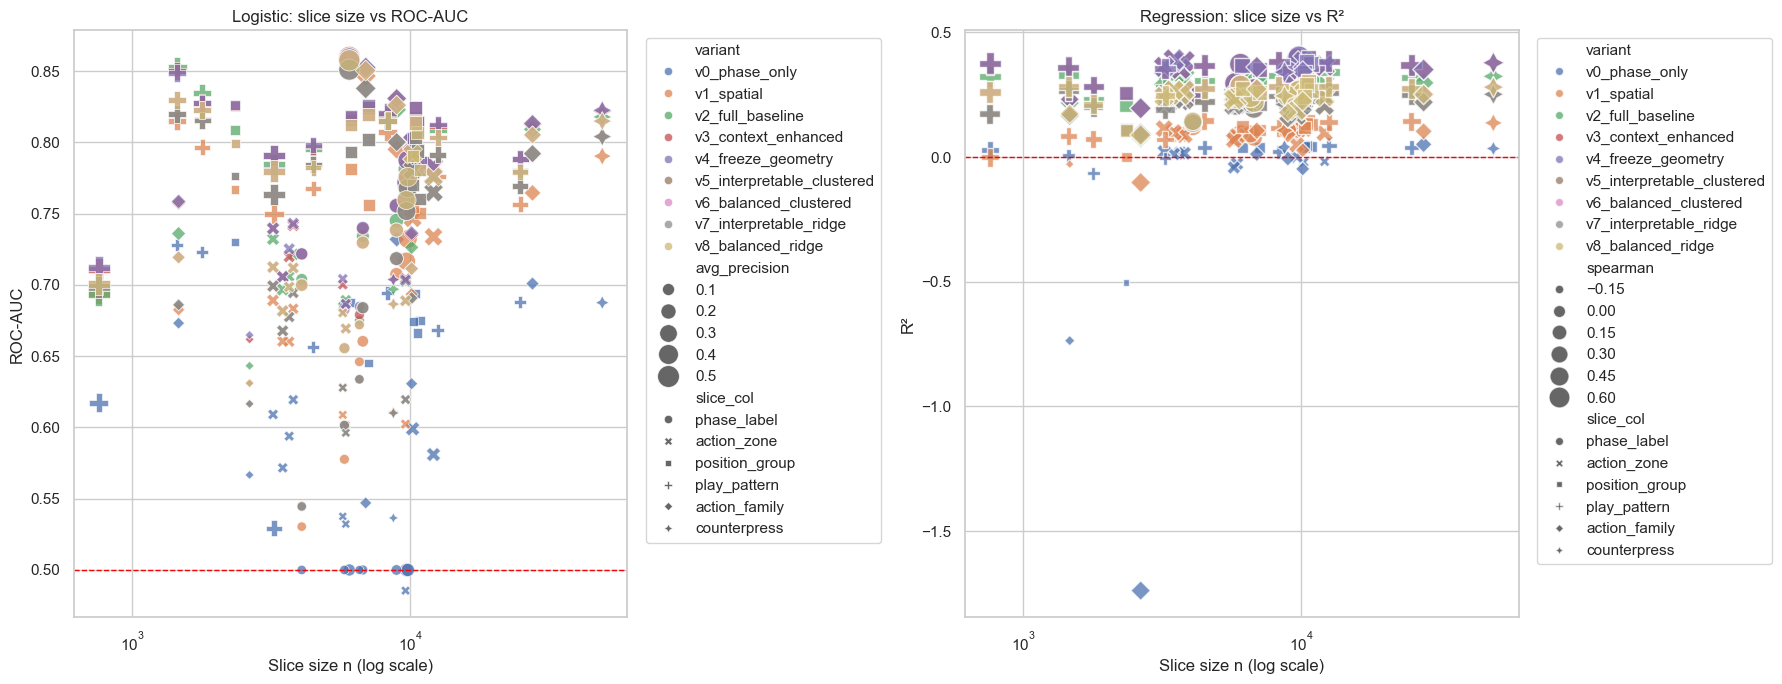

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(
    data=logistic,
    x='n', y='roc_auc', hue='variant', style='slice_col',
    size='avg_precision', sizes=(40, 260), alpha=0.75, ax=axes[0]
)
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=1)
axes[0].set_xscale('log')
axes[0].set_title('Logistic: slice size vs ROC-AUC')
axes[0].set_xlabel('Slice size n (log scale)')
axes[0].set_ylabel('ROC-AUC')

sns.scatterplot(
    data=regression,
    x='n', y='r2', hue='variant', style='slice_col',
    size='spearman', sizes=(40, 260), alpha=0.75, ax=axes[1]
)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xscale('log')
axes[1].set_title('Regression: slice size vs R²')
axes[1].set_xlabel('Slice size n (log scale)')
axes[1].set_ylabel('R²')

for ax in axes:
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 8. Best and weakest slices

In [9]:
print('Top logistic slices by ROC-AUC')
display(logistic.sort_values('roc_auc', ascending=False)[['variant', 'slice_col', 'slice_value', 'n', 'roc_auc', 'avg_precision']].head(25).round(4))

print('Weakest logistic slices by ROC-AUC')
display(logistic.sort_values('roc_auc', ascending=True)[['variant', 'slice_col', 'slice_value', 'n', 'roc_auc', 'avg_precision']].head(25).round(4))

print('Top regression slices by R²')
display(regression.sort_values('r2', ascending=False)[['variant', 'slice_col', 'slice_value', 'n', 'r2', 'rmse', 'mae', 'spearman']].head(25).round(4))

print('Weakest regression slices by R²')
display(regression.sort_values('r2', ascending=True)[['variant', 'slice_col', 'slice_value', 'n', 'r2', 'rmse', 'mae', 'spearman']].head(25).round(4))

Top logistic slices by ROC-AUC


,variant,slice_col,slice_value,n,roc_auc,avg_precision
44,v1_spatial,phase_label,second_ball,6035,0.8598,0.4879
84,v2_full_baseline,phase_label,second_ball,6035,0.8590,0.4480
164,v4_freeze_geometry,phase_label,second_ball,6035,0.8589,0.4642
124,v3_context_enhanced,phase_label,second_ball,6035,0.8582,0.4613
244,v6_balanced_clustered,phase_label,second_ball,6035,0.8575,0.4751
324,v8_balanced_ridge,phase_label,second_ball,6035,0.8575,0.4751
109,v2_full_baseline,play_pattern,From Kick Off,1453,0.8531,0.3410
192,v4_freeze_geometry,action_family,contest,6910,0.8526,0.4477
112,v2_full_baseline,action_family,contest,6910,0.8518,0.4322
152,v3_context_enhanced,action_family,contest,6910,0.8518,0.4448


Weakest logistic slices by ROC-AUC


,variant,slice_col,slice_value,n,roc_auc,avg_precision
14,v0_phase_only,action_zone,middle_third_center,9611,0.4855,0.0357
0,v0_phase_only,phase_label,box_defence,9686,0.5000,0.1410
2,v0_phase_only,phase_label,counterpress_after_loss,4070,0.5000,0.0310
1,v0_phase_only,phase_label,central_progression_defence,6748,0.5000,0.0428
4,v0_phase_only,phase_label,second_ball,6035,0.5000,0.1002
5,v0_phase_only,phase_label,settled_low_block,8915,0.5000,0.0582
6,v0_phase_only,phase_label,settled_mid_block,5795,0.5000,0.0319
3,v0_phase_only,phase_label,high_press,9797,0.5000,0.1393
7,v0_phase_only,phase_label,wide_defending,6560,0.5000,0.0197
24,v0_phase_only,play_pattern,From Corner,3235,0.5294,0.2058


Top regression slices by R²


,variant,slice_col,slice_value,n,r2,rmse,mae,spearman
163,v4_freeze_geometry,phase_label,high_press,9797,0.4012,0.3342,0.2488,0.7182
123,v3_context_enhanced,phase_label,high_press,9797,0.4008,0.3343,0.2489,0.7177
177,v4_freeze_geometry,position_group,centre_back,10607,0.3994,0.3185,0.2313,0.7019
137,v3_context_enhanced,position_group,centre_back,10607,0.3991,0.3186,0.2314,0.7016
160,v4_freeze_geometry,phase_label,box_defence,9686,0.3935,0.3683,0.2794,0.7212
120,v3_context_enhanced,phase_label,box_defence,9686,0.3933,0.3683,0.2794,0.7216
172,v4_freeze_geometry,action_zone,defensive_third_left_flank,3477,0.3914,0.3076,0.2262,0.7013
132,v3_context_enhanced,action_zone,defensive_third_left_flank,3477,0.3910,0.3077,0.2263,0.7011
170,v4_freeze_geometry,action_zone,attacking_third_right_flank,3794,0.3842,0.3334,0.2444,0.7150
150,v3_context_enhanced,play_pattern,From Throw In,12537,0.3840,0.3086,0.2229,0.6913


Weakest regression slices by R²


,variant,slice_col,slice_value,n,r2,rmse,mae,spearman
33,v0_phase_only,action_family,discipline,2643,-1.7391,0.3441,0.3222,0.4841
34,v0_phase_only,action_family,goalkeeper,1469,-0.7364,0.4268,0.3850,-0.0817
21,v0_phase_only,position_group,goalkeeper,2346,-0.5026,0.3974,0.3506,-0.1478
73,v1_spatial,action_family,discipline,2643,-0.1019,0.2183,0.1305,0.5358
28,v0_phase_only,play_pattern,From Keeper,1786,-0.0641,0.3300,0.2685,0.0366
35,v0_phase_only,action_family,intervention,10105,-0.0475,0.3979,0.3274,0.1140
16,v0_phase_only,action_zone,middle_third_right_flank,5717,-0.0418,0.2881,0.2285,0.0914
74,v1_spatial,action_family,goalkeeper,1469,-0.0286,0.3285,0.2441,-0.1501
15,v0_phase_only,action_zone,middle_third_left_flank,5862,-0.0263,0.2874,0.2300,0.1116
11,v0_phase_only,action_zone,defensive_third_center,10187,-0.0206,0.4313,0.3321,-0.0403


---
## 9. Slice dimension summaries

This answers: *which football dimensions are easiest or hardest for the model portfolio?*

Logistic summary by slice dimension


,slice_col,variant,slices,total_n,mean_roc_auc,median_roc_auc,mean_avg_precision
4,action_family,v4_freeze_geometry,6,57537,0.7761,0.7859,0.2625
3,action_family,v3_context_enhanced,6,57537,0.7750,0.7852,0.2615
2,action_family,v2_full_baseline,6,57537,0.7649,0.7726,0.2488
6,action_family,v6_balanced_clustered,6,57537,0.7573,0.7623,0.2484
8,action_family,v8_balanced_ridge,6,57537,0.7572,0.7622,0.2485
5,action_family,v5_interpretable_clustered,6,57537,0.7373,0.7414,0.2337
7,action_family,v7_interpretable_ridge,6,57537,0.7372,0.7414,0.2338
1,action_family,v1_spatial,6,57537,0.7355,0.7290,0.2298
0,action_family,v0_phase_only,6,57537,0.6417,0.6519,0.1106
13,action_zone,v4_freeze_geometry,9,57637,0.7323,0.7253,0.1767


Regression summary by slice dimension


,slice_col,variant,slices,total_n,mean_r2,median_r2,mean_rmse,mean_spearman
4,action_family,v4_freeze_geometry,6,57537,0.2960,0.3181,0.2889,0.6126
3,action_family,v3_context_enhanced,6,57537,0.2957,0.3179,0.2890,0.6124
2,action_family,v2_full_baseline,6,57537,0.2382,0.2587,0.3000,0.5749
6,action_family,v6_balanced_clustered,6,57537,0.1982,0.2019,0.3088,0.5501
8,action_family,v8_balanced_ridge,6,57537,0.1982,0.2019,0.3088,0.5501
7,action_family,v7_interpretable_ridge,6,57537,0.1759,0.1773,0.3137,0.5313
5,action_family,v5_interpretable_clustered,6,57537,0.1759,0.1773,0.3137,0.5313
1,action_family,v1_spatial,6,57537,0.0329,0.0592,0.3389,0.2545
0,action_family,v0_phase_only,6,57537,-0.4109,-0.0265,0.3868,0.1903
13,action_zone,v4_freeze_geometry,9,57637,0.3287,0.3618,0.3044,0.6875


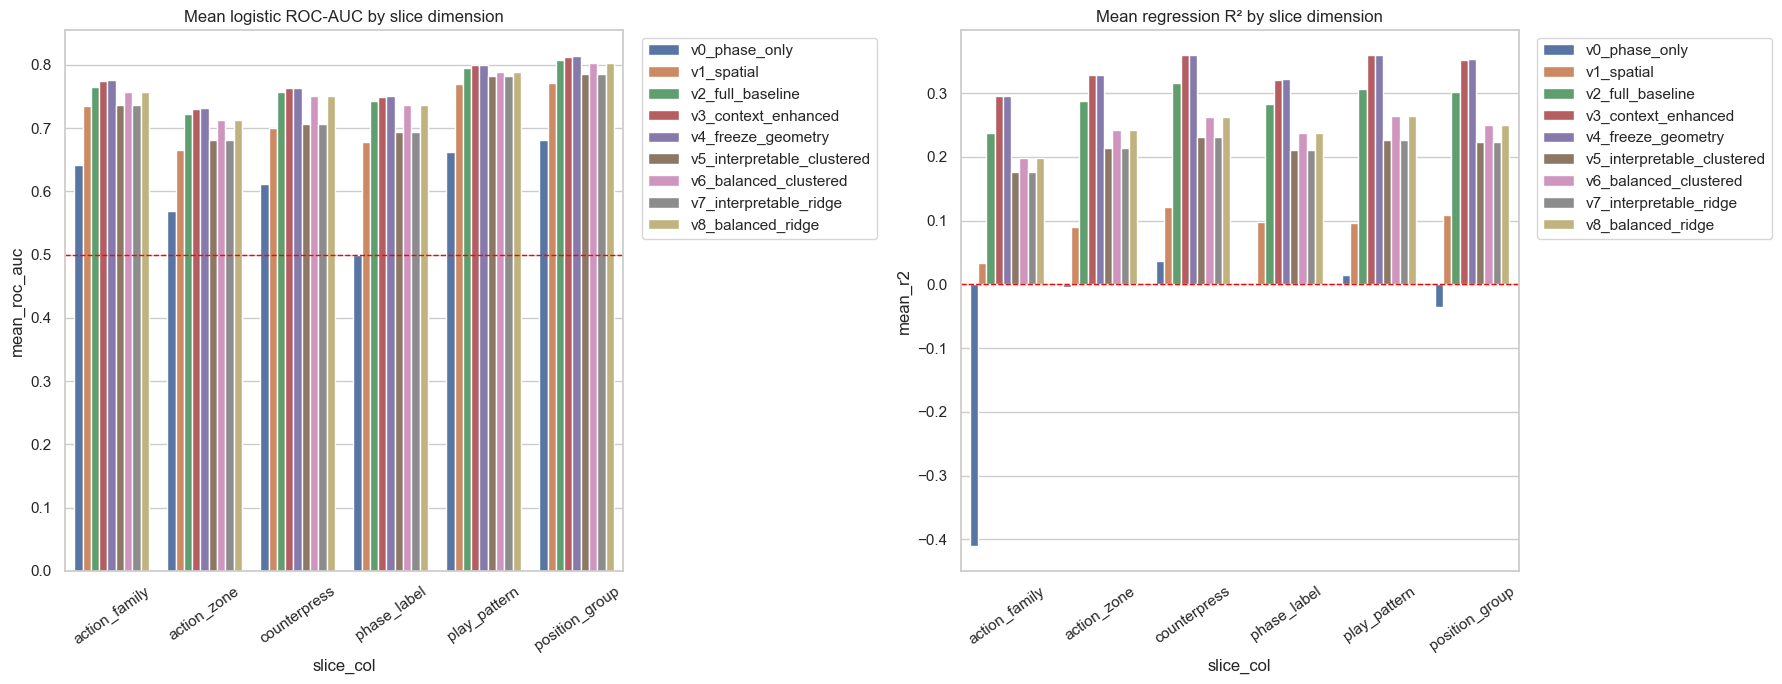

In [10]:
log_slice_summary = (
    logistic.groupby(['slice_col', 'variant'])
    .agg(
        slices=('slice_value', 'nunique'),
        total_n=('n', 'sum'),
        mean_roc_auc=('roc_auc', 'mean'),
        median_roc_auc=('roc_auc', 'median'),
        mean_avg_precision=('avg_precision', 'mean'),
    )
    .reset_index()
)

reg_slice_summary = (
    regression.groupby(['slice_col', 'variant'])
    .agg(
        slices=('slice_value', 'nunique'),
        total_n=('n', 'sum'),
        mean_r2=('r2', 'mean'),
        median_r2=('r2', 'median'),
        mean_rmse=('rmse', 'mean'),
        mean_spearman=('spearman', 'mean'),
    )
    .reset_index()
)

print('Logistic summary by slice dimension')
display(log_slice_summary.sort_values(['slice_col', 'mean_roc_auc'], ascending=[True, False]).round(4))
print('Regression summary by slice dimension')
display(reg_slice_summary.sort_values(['slice_col', 'mean_r2'], ascending=[True, False]).round(4))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.barplot(data=log_slice_summary, x='slice_col', y='mean_roc_auc', hue='variant', ax=axes[0])
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Mean logistic ROC-AUC by slice dimension')
axes[0].tick_params(axis='x', rotation=35)

sns.barplot(data=reg_slice_summary, x='slice_col', y='mean_r2', hue='variant', ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Mean regression R² by slice dimension')
axes[1].tick_params(axis='x', rotation=35)
for ax in axes:
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 10. Coach-readable interpretation

In [11]:
def coach_logistic_band(roc_auc: float, avg_precision: float) -> str:
    if pd.isna(roc_auc):
        return 'Not enough positives/negatives'
    if roc_auc >= 0.80:
        return 'Very readable immediate shot-risk pattern'
    if roc_auc >= 0.70:
        return 'Readable immediate shot-risk pattern'
    if roc_auc >= 0.60:
        return 'Some useful shot-risk signal'
    if roc_auc >= 0.52:
        return 'Weak shot-risk signal; use with video'
    return 'No reliable shot-risk separation'

def coach_regression_band(r2: float, spearman: float) -> str:
    if pd.isna(r2):
        return 'Not enough threat signal'
    if r2 >= 0.35 and spearman >= 0.60:
        return 'Strong threat-value and ranking pattern'
    if r2 >= 0.20 and spearman >= 0.45:
        return 'Useful threat pattern'
    if r2 >= 0.10:
        return 'Some threat signal'
    if r2 >= 0:
        return 'Weak but positive threat signal'
    return 'Threat model struggles in this context'

best_logistic_coach = best_logistic.copy()
best_logistic_coach['coach_read'] = best_logistic_coach.apply(lambda r: coach_logistic_band(r['roc_auc'], r['avg_precision']), axis=1)

best_regression_coach = best_regression.copy()
best_regression_coach['coach_read'] = best_regression_coach.apply(lambda r: coach_regression_band(r['r2'], r['spearman']), axis=1)

print('Coach read: best logistic model per slice')
display(best_logistic_coach[['slice_col', 'slice_value', 'n', 'variant', 'roc_auc', 'avg_precision', 'coach_read']].sort_values(['slice_col', 'roc_auc'], ascending=[True, False]).round(4))

print('Coach read: best regression model per slice')
display(best_regression_coach[['slice_col', 'slice_value', 'n', 'variant', 'r2', 'spearman', 'rmse', 'coach_read']].sort_values(['slice_col', 'r2'], ascending=[True, False]).round(4))

Coach read: best logistic model per slice


,slice_col,slice_value,n,variant,roc_auc,avg_precision,coach_read
0,action_family,contest,6910,v4_freeze_geometry,0.8526,0.4477,Very readable immediate shot-risk pattern
1,action_family,recovery,8932,v4_freeze_geometry,0.8308,0.4081,Very readable immediate shot-risk pattern
2,action_family,pressure,27478,v4_freeze_geometry,0.8133,0.3228,Very readable immediate shot-risk pattern
3,action_family,goalkeeper,1469,v4_freeze_geometry,0.7586,0.1861,Readable immediate shot-risk pattern
4,action_family,intervention,10105,v4_freeze_geometry,0.7363,0.1894,Readable immediate shot-risk pattern
5,action_family,discipline,2643,v4_freeze_geometry,0.6648,0.0213,Some useful shot-risk signal
6,action_zone,defensive_third_center,10187,v4_freeze_geometry,0.8000,0.4145,Readable immediate shot-risk pattern
7,action_zone,attacking_third_center,12110,v4_freeze_geometry,0.7833,0.4043,Readable immediate shot-risk pattern
8,action_zone,attacking_third_right_flank,3794,v4_freeze_geometry,0.7430,0.1221,Readable immediate shot-risk pattern
9,action_zone,defensive_third_right_flank,3210,v3_context_enhanced,0.7398,0.1409,Readable immediate shot-risk pattern


Coach read: best regression model per slice


,slice_col,slice_value,n,variant,r2,spearman,rmse,coach_read
0,action_family,contest,6910,v3_context_enhanced,0.3611,0.6739,0.3083,Strong threat-value and ranking pattern
1,action_family,pressure,27478,v4_freeze_geometry,0.3511,0.6581,0.3163,Strong threat-value and ranking pattern
2,action_family,intervention,10105,v3_context_enhanced,0.3429,0.6317,0.3151,Useful threat pattern
3,action_family,recovery,8932,v4_freeze_geometry,0.2933,0.5915,0.3236,Useful threat pattern
4,action_family,goalkeeper,1469,v4_freeze_geometry,0.2318,0.4586,0.2839,Useful threat pattern
5,action_family,discipline,2643,v4_freeze_geometry,0.1960,0.6617,0.1864,Some threat signal
6,action_zone,defensive_third_left_flank,3477,v4_freeze_geometry,0.3914,0.7013,0.3076,Strong threat-value and ranking pattern
7,action_zone,attacking_third_right_flank,3794,v4_freeze_geometry,0.3842,0.7150,0.3334,Strong threat-value and ranking pattern
8,action_zone,defensive_third_center,10187,v4_freeze_geometry,0.3826,0.6990,0.3354,Strong threat-value and ranking pattern
9,action_zone,attacking_third_center,12110,v4_freeze_geometry,0.3663,0.6899,0.3622,Strong threat-value and ranking pattern


---
## 11. Combined shot-risk + xT dashboard

This joins the best logistic and best regression result for each slice value.

,slice_col,slice_value,n,variant_logistic,roc_auc,avg_precision,variant_regression,r2,spearman,rmse,coach_summary
4,action_family,pressure,27478,v4_freeze_geometry,0.8133,0.3228,v4_freeze_geometry,0.3511,0.6581,0.3163,Clear tactical context: both shot risk and thr...
3,action_family,intervention,10105,v4_freeze_geometry,0.7363,0.1894,v3_context_enhanced,0.3429,0.6317,0.3151,Clear tactical context: both shot risk and thr...
5,action_family,recovery,8932,v4_freeze_geometry,0.8308,0.4081,v4_freeze_geometry,0.2933,0.5915,0.3236,Clear tactical context: both shot risk and thr...
0,action_family,contest,6910,v4_freeze_geometry,0.8526,0.4477,v3_context_enhanced,0.3611,0.6739,0.3083,Clear tactical context: both shot risk and thr...
1,action_family,discipline,2643,v4_freeze_geometry,0.6648,0.0213,v4_freeze_geometry,0.1960,0.6617,0.1864,Limited model signal; use video and tactical c...
2,action_family,goalkeeper,1469,v4_freeze_geometry,0.7586,0.1861,v4_freeze_geometry,0.2318,0.4586,0.2839,Clear tactical context: both shot risk and thr...
6,action_zone,attacking_third_center,12110,v4_freeze_geometry,0.7833,0.4043,v4_freeze_geometry,0.3663,0.6899,0.3622,Clear tactical context: both shot risk and thr...
9,action_zone,defensive_third_center,10187,v4_freeze_geometry,0.8000,0.4145,v4_freeze_geometry,0.3826,0.6990,0.3354,Clear tactical context: both shot risk and thr...
12,action_zone,middle_third_center,9611,v3_context_enhanced,0.7044,0.1097,v3_context_enhanced,0.2333,0.6371,0.2593,Clear tactical context: both shot risk and thr...
13,action_zone,middle_third_left_flank,5862,v2_full_baseline,0.6892,0.0914,v2_full_baseline,0.2592,0.6604,0.2442,"Threat builds clearly, but shot conversion is ..."


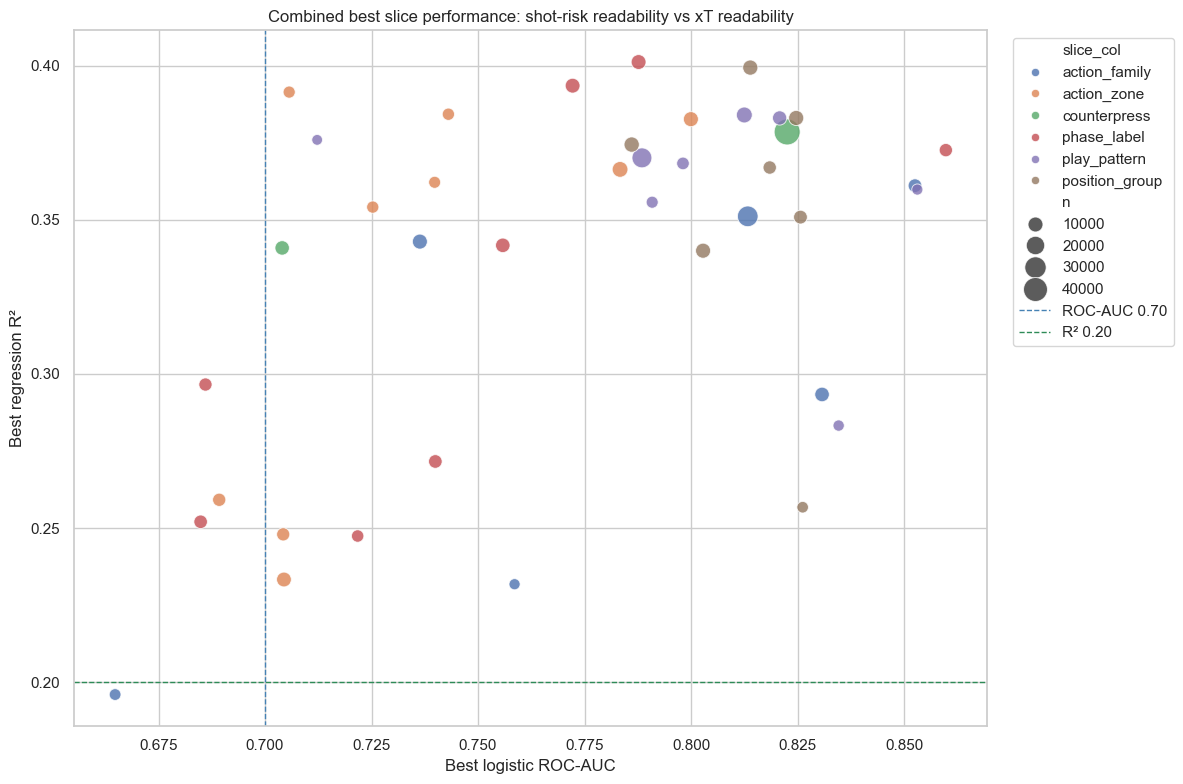

In [12]:
combined = best_logistic.merge(
    best_regression,
    on=['slice_col', 'slice_value', 'n'],
    how='outer',
    suffixes=('_logistic', '_regression'),
)

def combined_read(row):
    shot_good = pd.notna(row.get('roc_auc')) and row.get('roc_auc') >= 0.70
    xt_good = pd.notna(row.get('r2')) and row.get('r2') >= 0.20 and (pd.isna(row.get('spearman')) or row.get('spearman') >= 0.45)
    if shot_good and xt_good:
        return 'Clear tactical context: both shot risk and threat value are readable'
    if xt_good and not shot_good:
        return 'Threat builds clearly, but shot conversion is less predictable'
    if shot_good and not xt_good:
        return 'Shot occurrence is readable, but exact threat value is noisy'
    return 'Limited model signal; use video and tactical context before conclusions'

combined['coach_summary'] = combined.apply(combined_read, axis=1)
display(
    combined[[
        'slice_col', 'slice_value', 'n',
        'variant_logistic', 'roc_auc', 'avg_precision',
        'variant_regression', 'r2', 'spearman', 'rmse',
        'coach_summary',
    ]]
    .sort_values(['slice_col', 'n'], ascending=[True, False])
    .round(4)
)

fig, ax = plt.subplots(figsize=(12, 8))
plot_combined = combined.dropna(subset=['roc_auc', 'r2']).copy()
sns.scatterplot(
    data=plot_combined,
    x='roc_auc', y='r2', hue='slice_col', size='n', sizes=(60, 350), alpha=0.8, ax=ax
)
ax.axvline(0.70, color='steelblue', linestyle='--', linewidth=1, label='ROC-AUC 0.70')
ax.axhline(0.20, color='seagreen', linestyle='--', linewidth=1, label='R² 0.20')
ax.set_title('Combined best slice performance: shot-risk readability vs xT readability')
ax.set_xlabel('Best logistic ROC-AUC')
ax.set_ylabel('Best regression R²')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 12. Staff-room summary

In [13]:
print('=' * 100)
print('SLICES LATEST MODEL DASHBOARD SUMMARY')
print('=' * 100)

top_log = best_logistic.sort_values('roc_auc', ascending=False).iloc[0]
top_reg = best_regression.sort_values('r2', ascending=False).iloc[0]
most_log_wins = best_logistic['variant'].value_counts().idxmax()
most_reg_wins = best_regression['variant'].value_counts().idxmax()

print(f'Most frequent shot-risk winner: {most_log_wins}')
print(f'Most frequent xT-threat winner: {most_reg_wins}')
print()
print('Best immediate shot-risk context:')
print(f"  {top_log['slice_col']} = {top_log['slice_value']} | {top_log['variant']} | ROC-AUC={top_log['roc_auc']:.3f}, AP={top_log['avg_precision']:.3f}, n={int(top_log['n']):,}")
print()
print('Best xT-threat context:')
print(f"  {top_reg['slice_col']} = {top_reg['slice_value']} | {top_reg['variant']} | R²={top_reg['r2']:.3f}, Spearman={top_reg['spearman']:.3f}, n={int(top_reg['n']):,}")
print()
print('Coach rule:')
print('  Logistic target tells us whether a defensive context becomes a shot soon.')
print('  Regression target tells us how dangerous the opponent becomes, shot or no shot.')
print('  Slices where both are strong are the most actionable coaching contexts.')

SLICES LATEST MODEL DASHBOARD SUMMARY
Most frequent shot-risk winner: v4_freeze_geometry
Most frequent xT-threat winner: v4_freeze_geometry

Best immediate shot-risk context:
  phase_label = second_ball | v1_spatial | ROC-AUC=0.860, AP=0.488, n=6,035

Best xT-threat context:
  phase_label = high_press | v4_freeze_geometry | R²=0.401, Spearman=0.718, n=9,797

Coach rule:
  Logistic target tells us whether a defensive context becomes a shot soon.
  Regression target tells us how dangerous the opponent becomes, shot or no shot.
  Slices where both are strong are the most actionable coaching contexts.
